In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv


In [17]:
# ============================================
# CELL 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Dataset path
DATA_PATH = "/kaggle/input/datasets/dhruvb2028/student-academic-performance-dataset-for-ml/Students_Performance_dataset.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1194, 31)


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,How many hour do you spent daily in social media?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,How many hour do you spent daily on your skill development?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [18]:
# ============================================
# CELL 2: DATASET OVERVIEW
# ============================================

print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
for i, col in enumerate(df.columns, 1):
    print(i, "->", col)

print("\n========== DATA TYPES ==========")
display(df.dtypes.to_frame("Data Type"))

print("\n========== FIRST 5 ROWS ==========")
display(df.head())

print("\n========== LAST 5 ROWS ==========")
display(df.tail())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all").T)

========== DATASET SHAPE ==========
(1194, 31)

========== COLUMN NAMES ==========
1 -> University Admission year
2 -> Gender
3 -> Age
4 -> H.S.C passing year
5 -> Program
6 -> Current Semester
7 -> Do you have meritorious scholarship ?
8 -> Do you use University transportation?
9 -> How many hour do you study daily?
10 -> How many times do you seat for study in a day?
11 -> What is your preferable learning mode?
12 -> Do you use smart phone?
13 -> Do you have personal Computer?
14 -> How many hour do you spent daily in social media?
15 -> Status of your English language proficiency
16 -> Average attendance on class
17 -> Did you ever fall in probation?
18 -> Did you ever got suspension?
19 -> Do you attend in teacher consultancy for any kind of academical problems?
20 -> What are the skills do you have ?
21 -> How many hour do you spent daily on your skill development?
22 -> What is you interested area?
23 -> What is your relationship status?
24 -> Are you engaged with any co-curricul

,Data Type
University Admission year,int64
Gender,object
Age,int64
H.S.C passing year,int64
Program,object
Current Semester,int64
Do you have meritorious scholarship ?,object
Do you use University transportation?,object
How many hour do you study daily?,int64
How many times do you seat for study in a day?,int64



========== FIRST 5 ROWS ==========


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,How many hour do you spent daily in social media?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,How many hour do you spent daily on your skill development?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000



========== LAST 5 ROWS ==========


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,How many hour do you spent daily in social media?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,How many hour do you spent daily on your skill development?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
1189,2021,Female,20,2020,BCSE,8,No,Yes,1,2,Online,Yes,Yes,2,Basic,46,Yes,No,No,Cyber security,2,Data Science,Relationship,Yes,Bachelor,No,2.65,No,3.77,100,180000
1190,2022,Male,23,2020,BCSE,8,Yes,Yes,4,2,Offline,Yes,Yes,4,Basic,100,Yes,No,Yes,Programming,2,Software,Single,Yes,Bachelor,No,2.50,No,2.22,18,200000
1191,2021,Male,22,2020,BCSE,9,No,Yes,3,2,Offline,Yes,No,2,Basic,100,Yes,No,No,Networking,2,Hardware,Married,Yes,Family,No,1.56,No,2.78,100,200000
1192,2019,Female,25,2018,BCSE,11,No,Yes,5,3,Offline,Yes,Yes,3,Intermediate,100,No,No,Yes,Web development,4,Software,Single,No,Bachelor,No,1.40,No,2.52,136,210000
1193,2018,Female,23,2017,BCSE,11,No,Yes,3,2,Online,Yes,Yes,5,Intermediate,100,No,No,No,Networking,1,Hardware,Relationship,Yes,Bachelor,No,1.34,No,2.88,88,250000



========== STATISTICAL SUMMARY ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
University Admission year,1194.0,NaN,NaN,NaN,2020.515075,1.354954,2013.0,2020.0,2021.0,2022.0,2023.0
Gender,1194,2,Male,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1194.0,NaN,NaN,NaN,21.343384,1.613338,18.0,20.0,21.0,22.0,27.0
H.S.C passing year,1194.0,NaN,NaN,NaN,2019.214405,1.38096,2012.0,2019.0,2020.0,2020.0,2028.0
Program,1194,1,BCSE,1194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Semester,1194.0,NaN,NaN,NaN,6.539363,3.809884,1.0,3.0,7.0,10.0,24.0
Do you have meritorious scholarship ?,1194,2,No,671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do you use University transportation?,1194,2,No,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
How many hour do you study daily?,1194.0,NaN,NaN,NaN,3.131491,1.649597,0.0,2.0,3.0,4.0,13.0
How many times do you seat for study in a day?,1194.0,NaN,NaN,NaN,1.940536,0.856305,0.0,1.0,2.0,2.0,7.0


In [19]:
# ============================================
# CELL 2: DATASET OVERVIEW
# ============================================

print("========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
for i, col in enumerate(df.columns, 1):
    print(i, "->", col)

print("\n========== DATA TYPES ==========")
display(df.dtypes.to_frame("Data Type"))

print("\n========== FIRST 5 ROWS ==========")
display(df.head())

print("\n========== LAST 5 ROWS ==========")
display(df.tail())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all").T)

========== DATASET SHAPE ==========
(1194, 31)

========== COLUMN NAMES ==========
1 -> University Admission year
2 -> Gender
3 -> Age
4 -> H.S.C passing year
5 -> Program
6 -> Current Semester
7 -> Do you have meritorious scholarship ?
8 -> Do you use University transportation?
9 -> How many hour do you study daily?
10 -> How many times do you seat for study in a day?
11 -> What is your preferable learning mode?
12 -> Do you use smart phone?
13 -> Do you have personal Computer?
14 -> How many hour do you spent daily in social media?
15 -> Status of your English language proficiency
16 -> Average attendance on class
17 -> Did you ever fall in probation?
18 -> Did you ever got suspension?
19 -> Do you attend in teacher consultancy for any kind of academical problems?
20 -> What are the skills do you have ?
21 -> How many hour do you spent daily on your skill development?
22 -> What is you interested area?
23 -> What is your relationship status?
24 -> Are you engaged with any co-curricul

,Data Type
University Admission year,int64
Gender,object
Age,int64
H.S.C passing year,int64
Program,object
Current Semester,int64
Do you have meritorious scholarship ?,object
Do you use University transportation?,object
How many hour do you study daily?,int64
How many times do you seat for study in a day?,int64



========== FIRST 5 ROWS ==========


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,How many hour do you spent daily in social media?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,How many hour do you spent daily on your skill development?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000



========== LAST 5 ROWS ==========


,University Admission year,Gender,Age,H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily?,How many times do you seat for study in a day?,What is your preferable learning mode?,Do you use smart phone?,Do you have personal Computer?,How many hour do you spent daily in social media?,Status of your English language proficiency,Average attendance on class,Did you ever fall in probation?,Did you ever got suspension?,Do you attend in teacher consultancy for any kind of academical problems?,What are the skills do you have ?,How many hour do you spent daily on your skill development?,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly family income?
1189,2021,Female,20,2020,BCSE,8,No,Yes,1,2,Online,Yes,Yes,2,Basic,46,Yes,No,No,Cyber security,2,Data Science,Relationship,Yes,Bachelor,No,2.65,No,3.77,100,180000
1190,2022,Male,23,2020,BCSE,8,Yes,Yes,4,2,Offline,Yes,Yes,4,Basic,100,Yes,No,Yes,Programming,2,Software,Single,Yes,Bachelor,No,2.50,No,2.22,18,200000
1191,2021,Male,22,2020,BCSE,9,No,Yes,3,2,Offline,Yes,No,2,Basic,100,Yes,No,No,Networking,2,Hardware,Married,Yes,Family,No,1.56,No,2.78,100,200000
1192,2019,Female,25,2018,BCSE,11,No,Yes,5,3,Offline,Yes,Yes,3,Intermediate,100,No,No,Yes,Web development,4,Software,Single,No,Bachelor,No,1.40,No,2.52,136,210000
1193,2018,Female,23,2017,BCSE,11,No,Yes,3,2,Online,Yes,Yes,5,Intermediate,100,No,No,No,Networking,1,Hardware,Relationship,Yes,Bachelor,No,1.34,No,2.88,88,250000



========== STATISTICAL SUMMARY ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
University Admission year,1194.0,NaN,NaN,NaN,2020.515075,1.354954,2013.0,2020.0,2021.0,2022.0,2023.0
Gender,1194,2,Male,672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1194.0,NaN,NaN,NaN,21.343384,1.613338,18.0,20.0,21.0,22.0,27.0
H.S.C passing year,1194.0,NaN,NaN,NaN,2019.214405,1.38096,2012.0,2019.0,2020.0,2020.0,2028.0
Program,1194,1,BCSE,1194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Semester,1194.0,NaN,NaN,NaN,6.539363,3.809884,1.0,3.0,7.0,10.0,24.0
Do you have meritorious scholarship ?,1194,2,No,671,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do you use University transportation?,1194,2,No,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
How many hour do you study daily?,1194.0,NaN,NaN,NaN,3.131491,1.649597,0.0,2.0,3.0,4.0,13.0
How many times do you seat for study in a day?,1194.0,NaN,NaN,NaN,1.940536,0.856305,0.0,1.0,2.0,2.0,7.0


In [20]:
# ============================================
# CELL 3: DATA QUALITY CHECK
# ============================================

print("========== MISSING VALUES ==========")

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values("Missing Count", ascending=False)

display(missing)

print("\n========== DUPLICATE ROWS ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

print("\n========== UNIQUE VALUES ==========")

for col in df.columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].dropna().unique()[:20])

========== MISSING VALUES ==========


,Missing Count,Missing Percentage
What are the skills do you have ?,1,0.08
Gender,0,0.00
University Admission year,0,0.00
H.S.C passing year,0,0.00
Program,0,0.00
Current Semester,0,0.00
Age,0,0.00
Do you use University transportation?,0,0.00
How many hour do you study daily?,0,0.00
How many times do you seat for study in a day?,0,0.00



========== DUPLICATE ROWS ==========
Number of duplicate rows: 0

========== UNIQUE VALUES ==========

University Admission year
Unique values: 11
[2018 2021 2020 2022 2019 2017 2015 2016 2014 2013 2023]

Gender
Unique values: 2
['Male' 'Female']

Age
Unique values: 10
[24 22 21 20 19 25 23 26 27 18]

H.S.C passing year
Unique values: 12
[2016 2020 2019 2018 2021 2017 2022 2012 2014 2015 2028 2013]

Program
Unique values: 1
['BCSE']

Current Semester
Unique values: 22
[12  4  5  2 11  8 10 13  9 15 14 21  6  7 22  1 18 17  3 19]

Do you have meritorious scholarship ?
Unique values: 2
['Yes' 'No']

Do you use University transportation?
Unique values: 2
['No' 'Yes']

How many hour do you study daily?
Unique values: 12
[ 3  1  2  5  6  4  8  7  9  0 10 13]

How many times do you seat for study in a day?
Unique values: 8
[2 3 1 4 5 7 0 6]

What is your preferable learning mode?
Unique values: 2
['Offline' 'Online']

Do you use smart phone?
Unique values: 2
['Yes' 'No']

Do you have person

In [21]:
# ============================================
# CELL 4: DATA CLEANING
# ============================================

# Make a copy so original data remains untouched
data = df.copy()

# Clean column names
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Replace common missing-value representations
missing_values = ["?", "NA", "N/A", "na", "n/a", "null", "NULL", ""]

data = data.replace(missing_values, np.nan)

# Remove duplicate rows
before_duplicates = len(data)

data = data.drop_duplicates()

after_duplicates = len(data)

print("Duplicate rows removed:", before_duplicates - after_duplicates)

# Display missing values after cleaning
print("\n========== MISSING VALUES AFTER CLEANING ==========")

missing_after = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage": (
        data.isnull().sum() / len(data) * 100
    ).round(2)
})

display(
    missing_after[
        missing_after["Missing Count"] > 0
    ].sort_values("Missing Count", ascending=False)
)

print("\nCleaned dataset shape:", data.shape)

display(data.head())

Duplicate rows removed: 0

========== MISSING VALUES AFTER CLEANING ==========


,Missing Count,Missing Percentage
what_are_the_skills_do_you_have_?,1,0.08



Cleaned dataset shape: (1194, 31)


,university_admission_year,gender,age,h.s.c_passing_year,program,current_semester,do_you_have_meritorious_scholarship_?,do_you_use_university_transportation?,how_many_hour_do_you_study_daily?,how_many_times_do_you_seat_for_study_in_a_day?,what_is_your_preferable_learning_mode?,do_you_use_smart_phone?,do_you_have_personal_computer?,how_many_hour_do_you_spent_daily_in_social_media?,status_of_your_english_language_proficiency,average_attendance_on_class,did_you_ever_fall_in_probation?,did_you_ever_got_suspension?,do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems?,what_are_the_skills_do_you_have_?,how_many_hour_do_you_spent_daily_on_your_skill_development?,what_is_you_interested_area?,what_is_your_relationship_status?,are_you_engaged_with_any_co_curriculum_activities?,with_whom_you_are_living_with?,do_you_have_any_health_issues?,what_was_your_previous_sgpa?,do_you_have_any_physical_disabilities?,what_is_your_current_cgpa?,how_many_credit_did_you_have_completed?,what_is_your_monthly_family_income?
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


In [22]:
# ============================================
# CELL 5: IDENTIFY TARGET VARIABLE
# ============================================

print("Available columns:")
print(list(data.columns))

# Expected target
possible_targets = [
    "student_status",
    "status",
    "student_status_",
    "performance",
    "academic_performance"
]

TARGET = None

for target in possible_targets:
    if target in data.columns:
        TARGET = target
        break

if TARGET is None:
    print("\nTarget column was not automatically found.")
    print("Please check the column list above.")
else:
    print("\nTarget column detected:", TARGET)

    print("\nTarget distribution:")
    display(data[TARGET].value_counts(dropna=False).to_frame("Count"))

    print("\nTarget percentage:")
    display(
        (data[TARGET].value_counts(normalize=True) * 100)
        .round(2)
        .to_frame("Percentage")
    )

Available columns:
['university_admission_year', 'gender', 'age', 'h.s.c_passing_year', 'program', 'current_semester', 'do_you_have_meritorious_scholarship_?', 'do_you_use_university_transportation?', 'how_many_hour_do_you_study_daily?', 'how_many_times_do_you_seat_for_study_in_a_day?', 'what_is_your_preferable_learning_mode?', 'do_you_use_smart_phone?', 'do_you_have_personal_computer?', 'how_many_hour_do_you_spent_daily_in_social_media?', 'status_of_your_english_language_proficiency', 'average_attendance_on_class', 'did_you_ever_fall_in_probation?', 'did_you_ever_got_suspension?', 'do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems?', 'what_are_the_skills_do_you_have_?', 'how_many_hour_do_you_spent_daily_on_your_skill_development?', 'what_is_you_interested_area?', 'what_is_your_relationship_status?', 'are_you_engaged_with_any_co_curriculum_activities?', 'with_whom_you_are_living_with?', 'do_you_have_any_health_issues?', 'what_was_your_previous_sgpa?', 'do_you_hav

In [23]:
# ============================================
# CELL 6: HANDLE MISSING VALUES
# ============================================

# Numeric columns
numeric_columns = data.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns

# Categorical columns
categorical_columns = data.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numeric columns:", len(numeric_columns))
print("Categorical columns:", len(categorical_columns))

# Fill numerical missing values with median
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

print("\nMissing values after treatment:")

total_missing = data.isnull().sum().sum()

print("Total missing values:", total_missing)

Numeric columns: 12
Categorical columns: 19

Missing values after treatment:
Total missing values: 0


In [24]:
# ============================================
# CELL 7: PROJECT KPIs
# ============================================

print("========================================")
print("        STUDENT ANALYTICS KPIs")
print("========================================")

total_students = len(data)

print("\nTotal Students:", total_students)

# Target-based KPIs
if TARGET is not None:

    target_counts = data[TARGET].value_counts()

    print("\nStudent Status Distribution:")
    display(target_counts.to_frame("Students"))

    target_percentage = (
        data[TARGET]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nStudent Status Percentage:")
    display(target_percentage.to_frame("Percentage"))

# Numeric KPI summary
print("\nNumeric KPI Summary:")

if len(numeric_columns) > 0:
    kpi_summary = data[numeric_columns].describe().T[
        ["mean", "min", "max"]
    ]

    display(kpi_summary)

        STUDENT ANALYTICS KPIs

Total Students: 1194

Numeric KPI Summary:


,mean,min,max
university_admission_year,2020.515075,2013.0,2023.0
age,21.343384,18.0,27.0
h.s.c_passing_year,2019.214405,2012.0,2028.0
current_semester,6.539363,1.0,24.0
how_many_hour_do_you_study_daily?,3.131491,0.0,13.0
how_many_times_do_you_seat_for_study_in_a_day?,1.940536,0.0,7.0
how_many_hour_do_you_spent_daily_in_social_media?,3.289782,0.0,20.0
how_many_hour_do_you_spent_daily_on_your_skill_development?,2.185092,0.0,12.0
what_was_your_previous_sgpa?,2.683945,0.0,4.0
what_is_your_current_cgpa?,3.165603,0.0,4.0


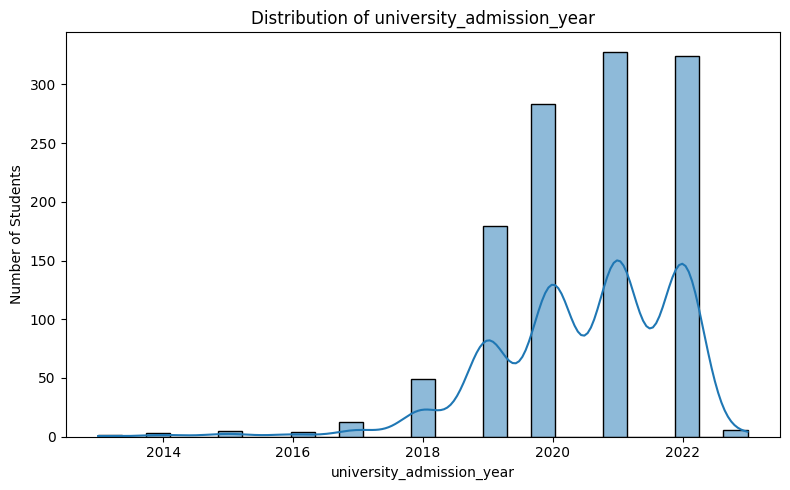

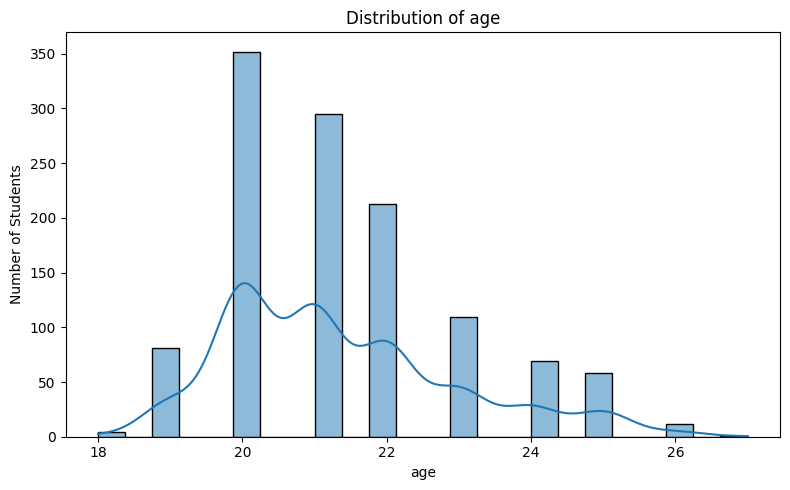

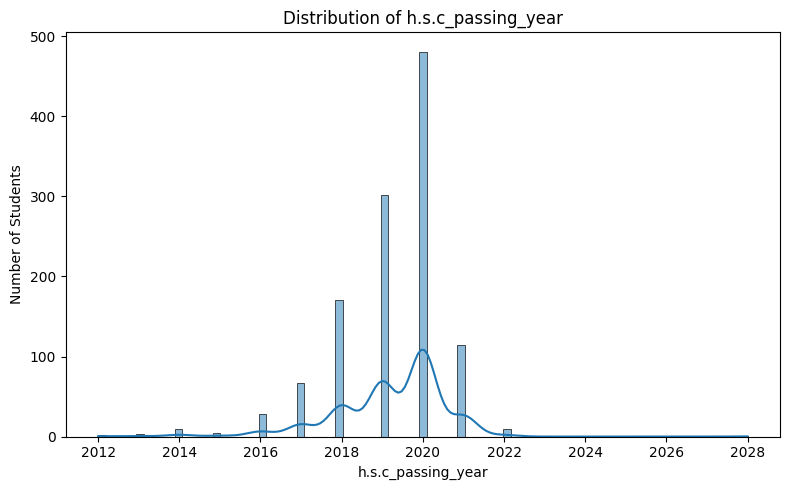

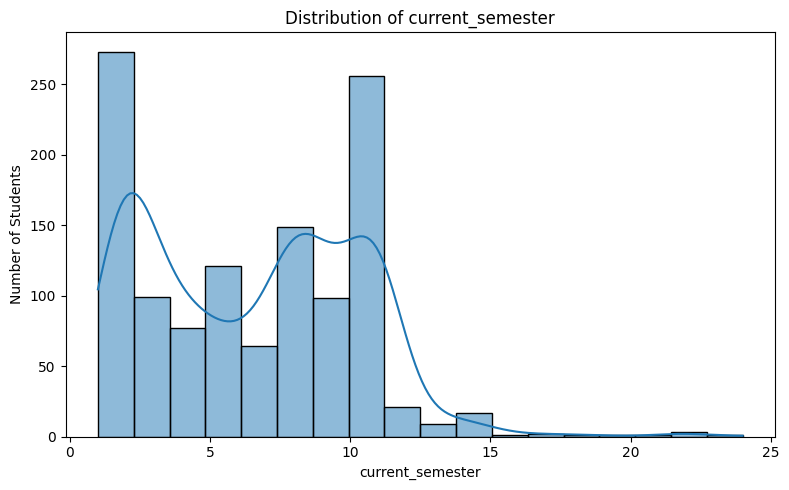

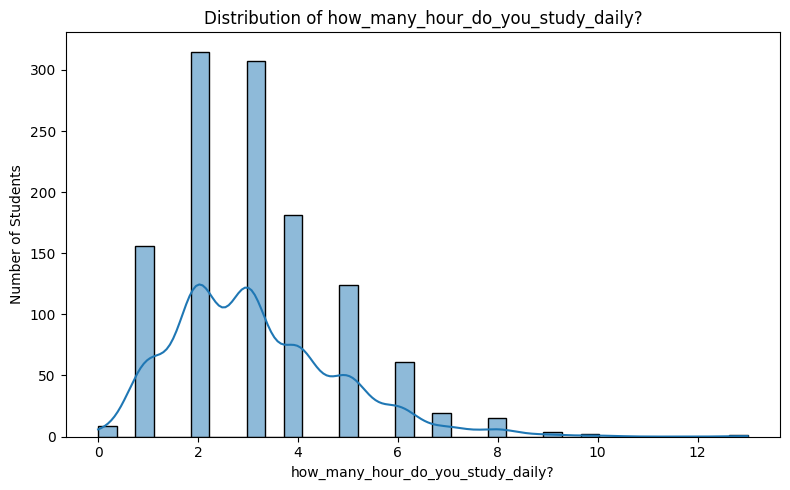

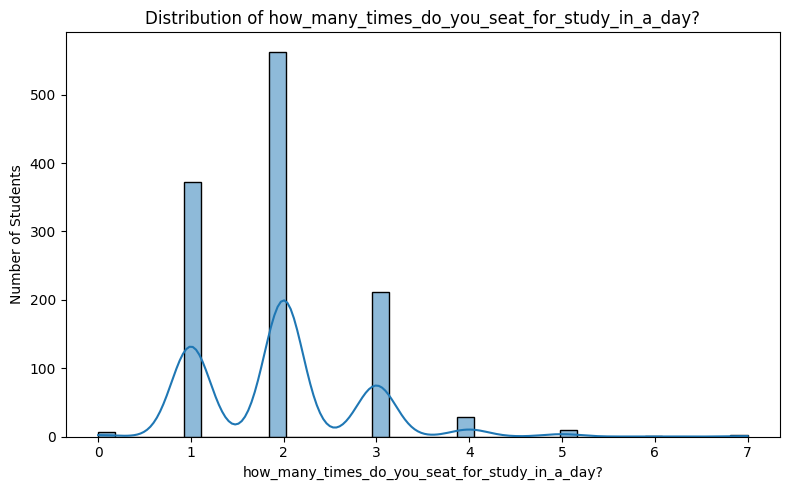

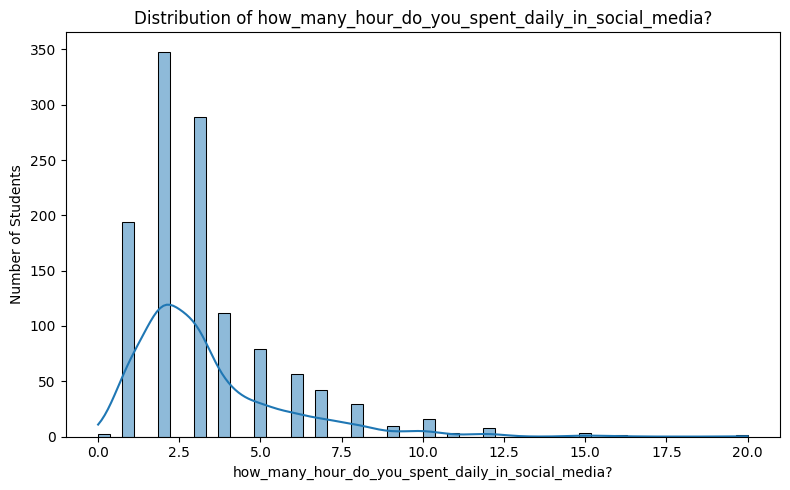

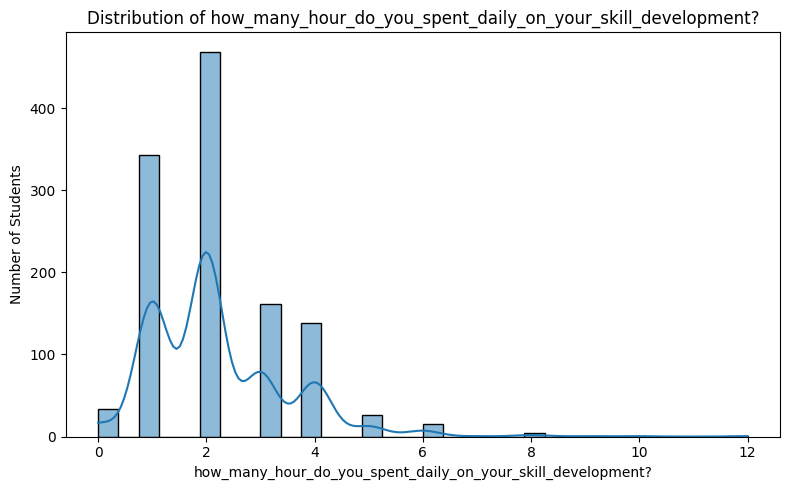

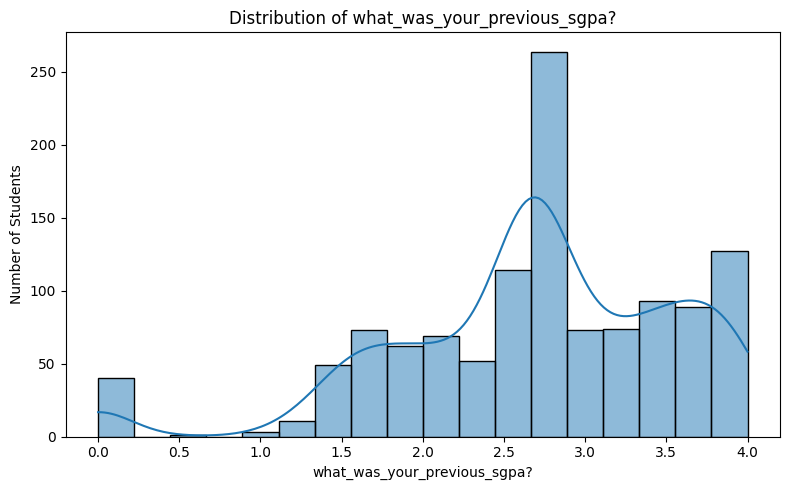

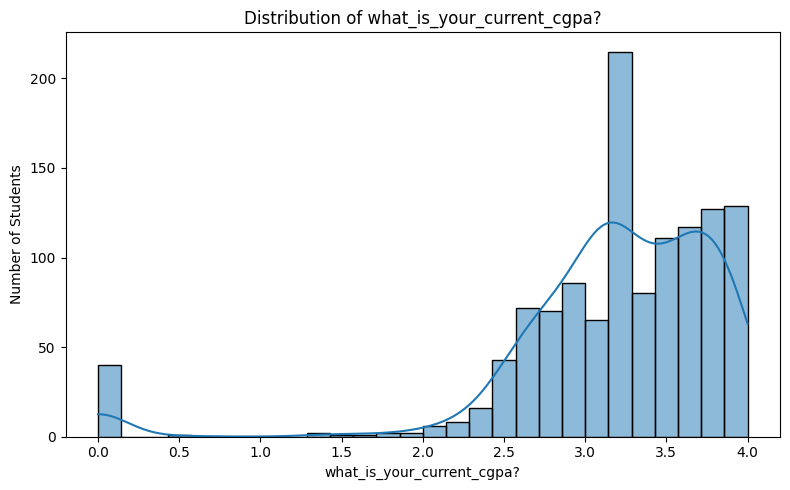

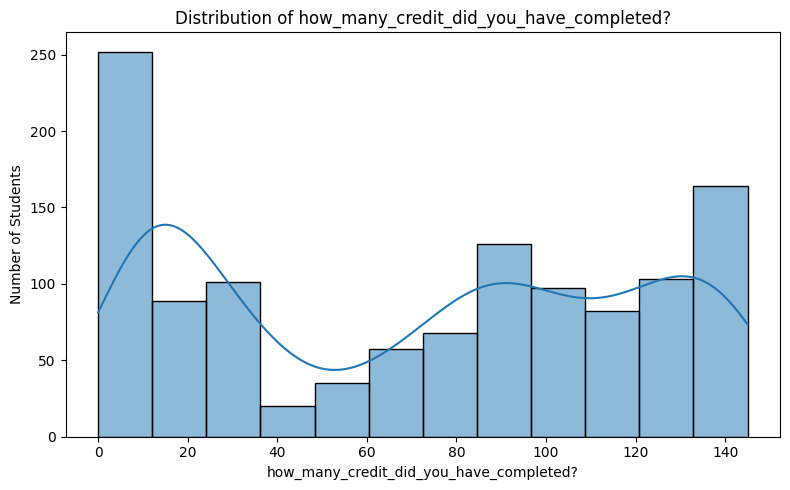

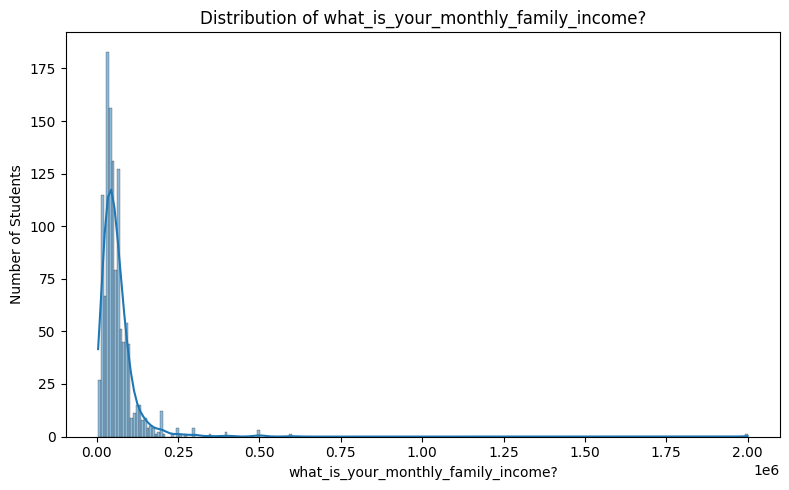

In [25]:
# ============================================
# CELL 8A: NUMERICAL DISTRIBUTIONS
# ============================================

numeric_columns = data.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns

for col in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Students")

    plt.tight_layout()
    plt.show()

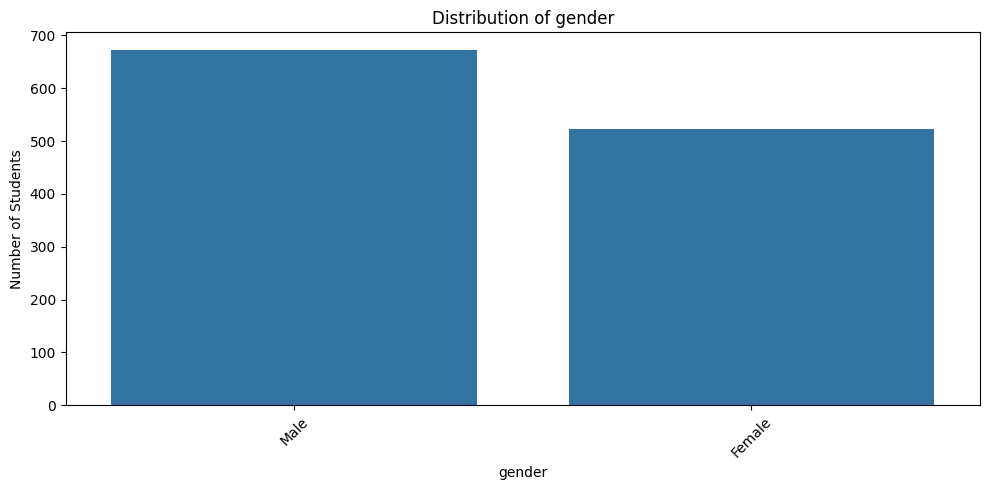

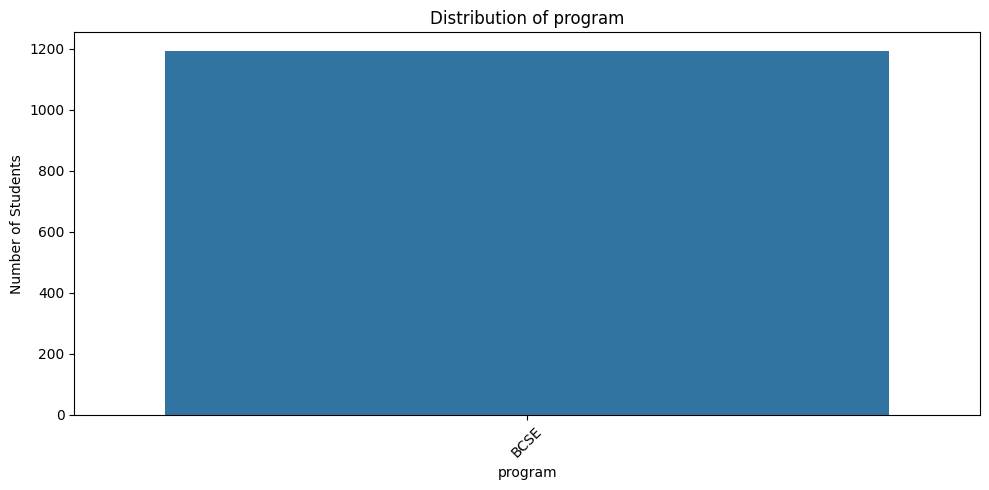

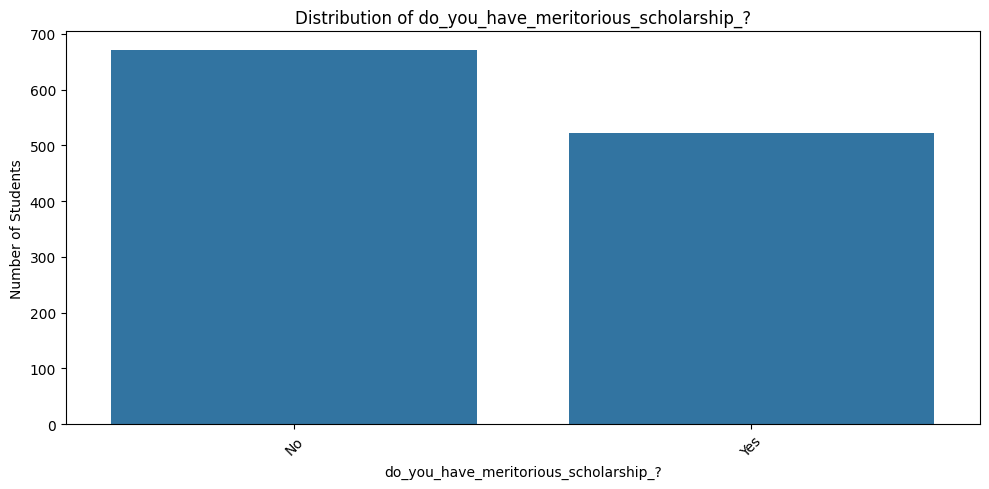

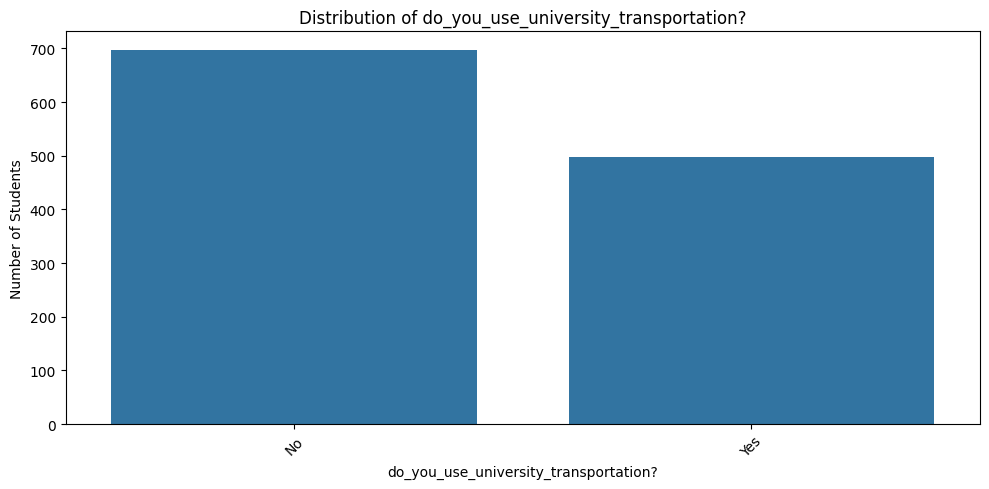

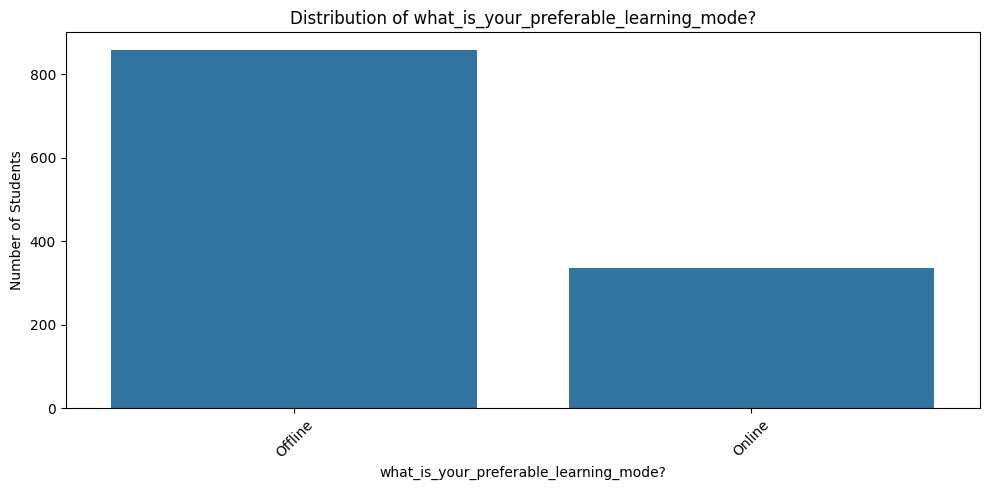

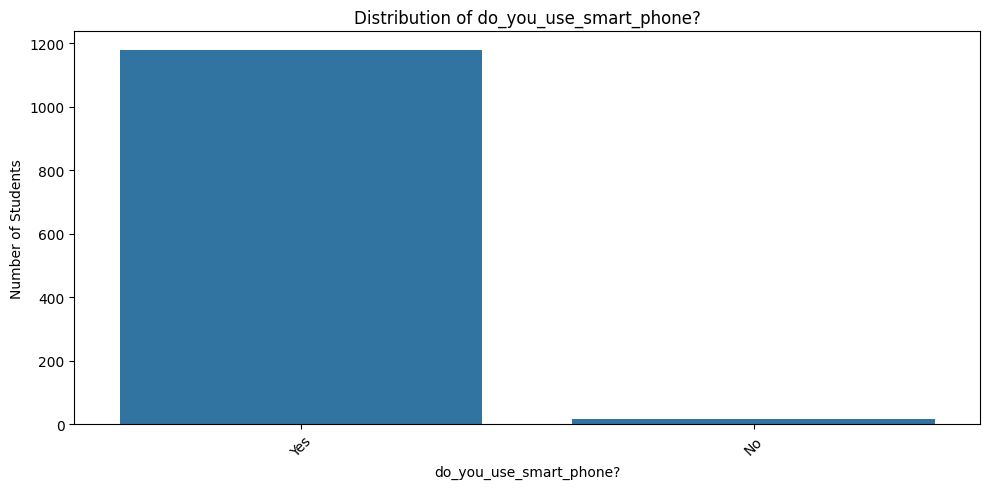

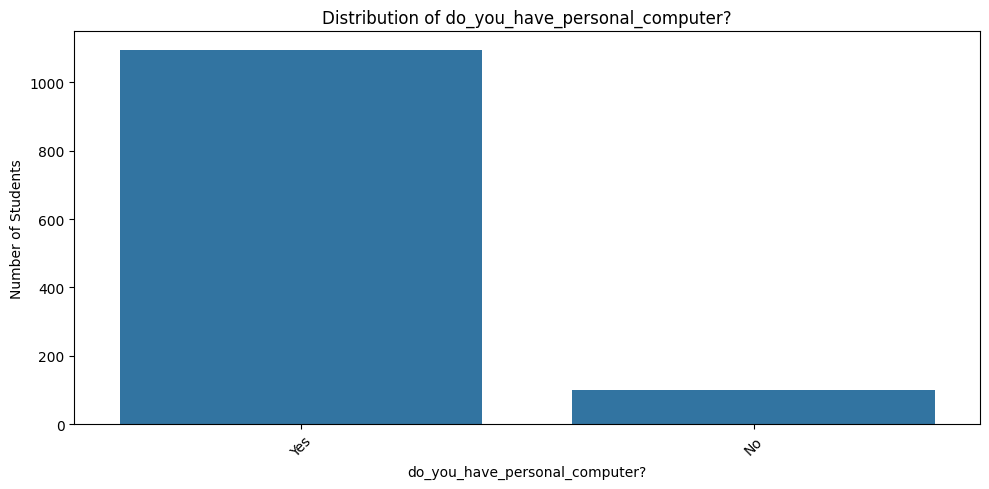

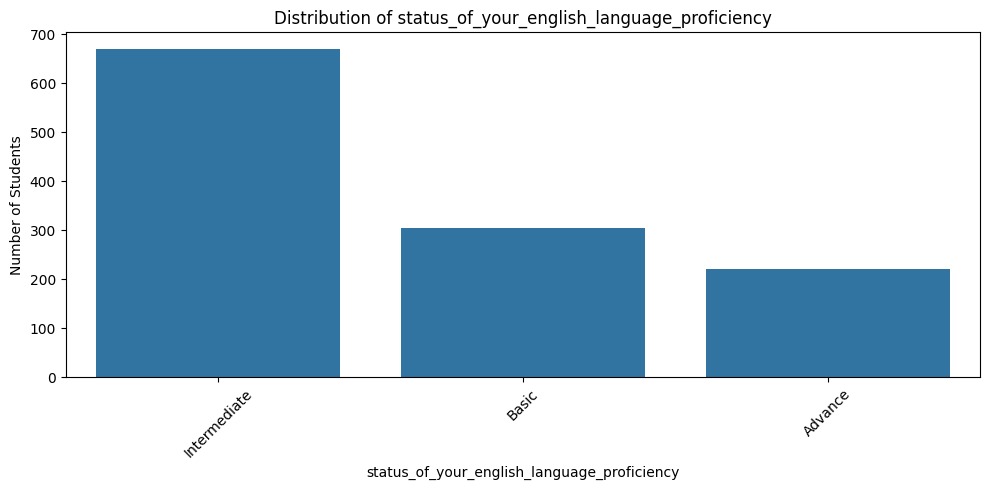

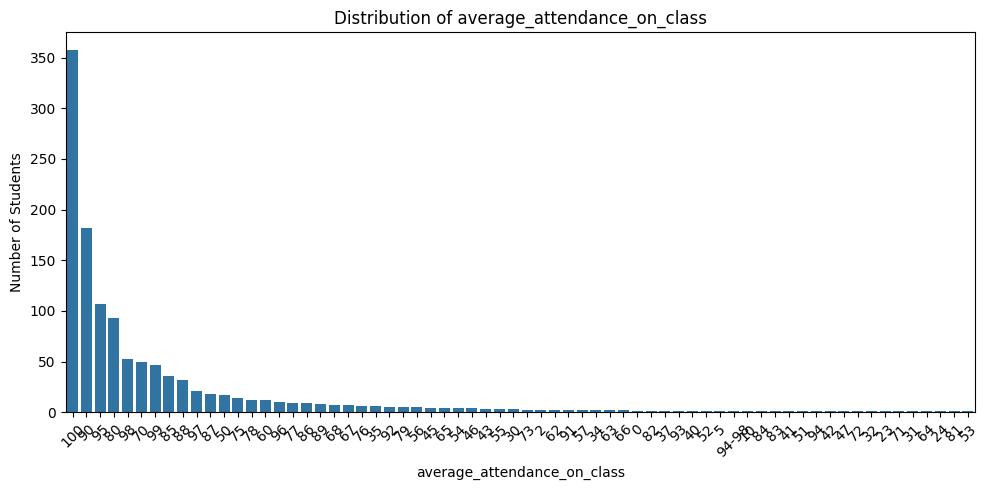

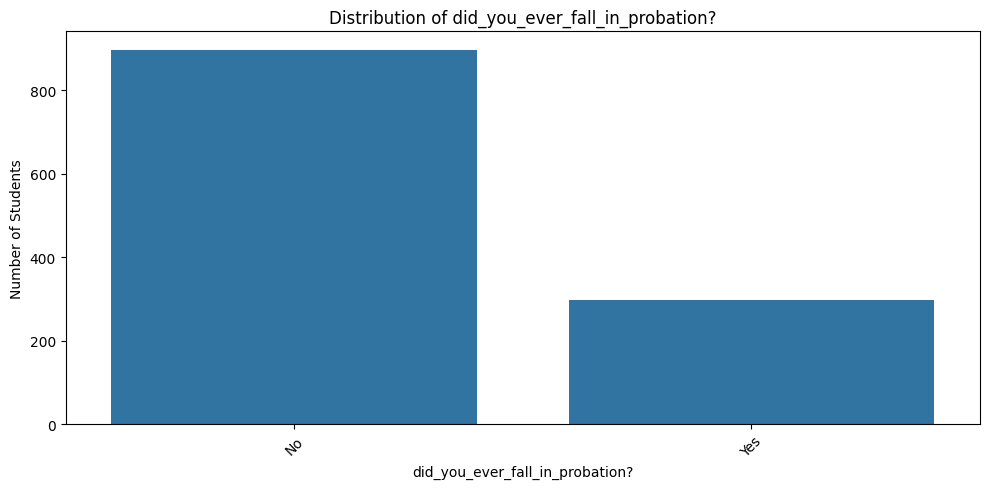

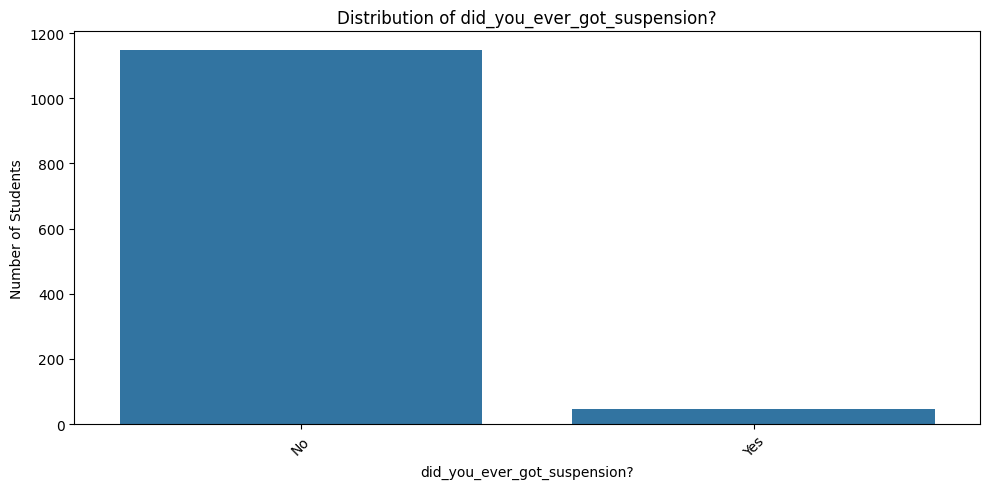

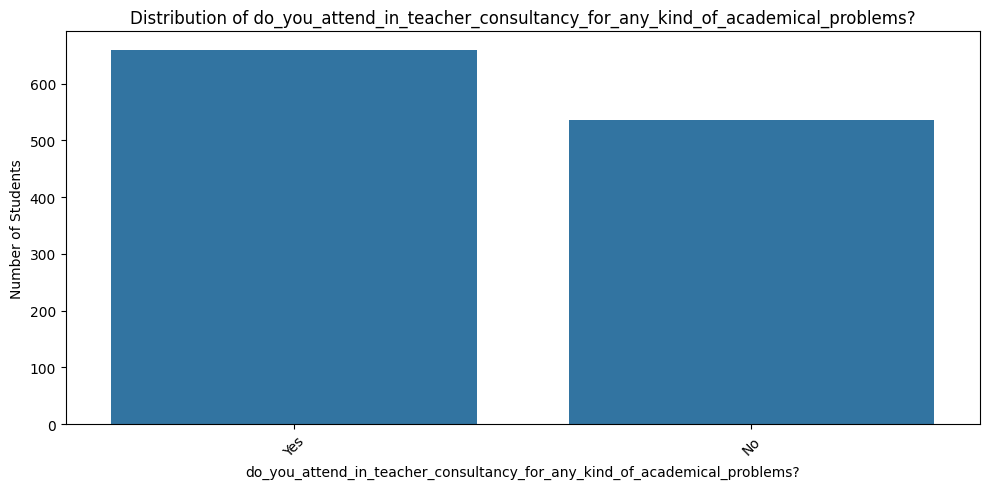

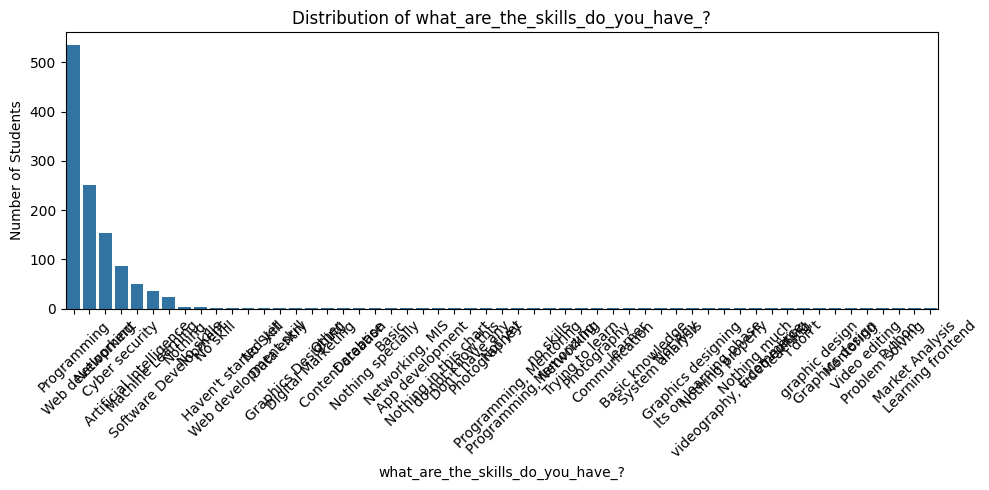

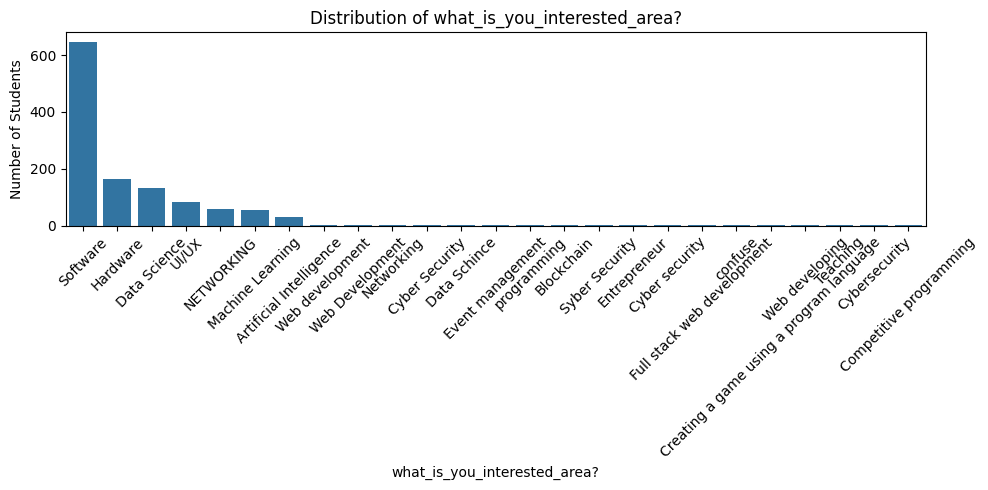

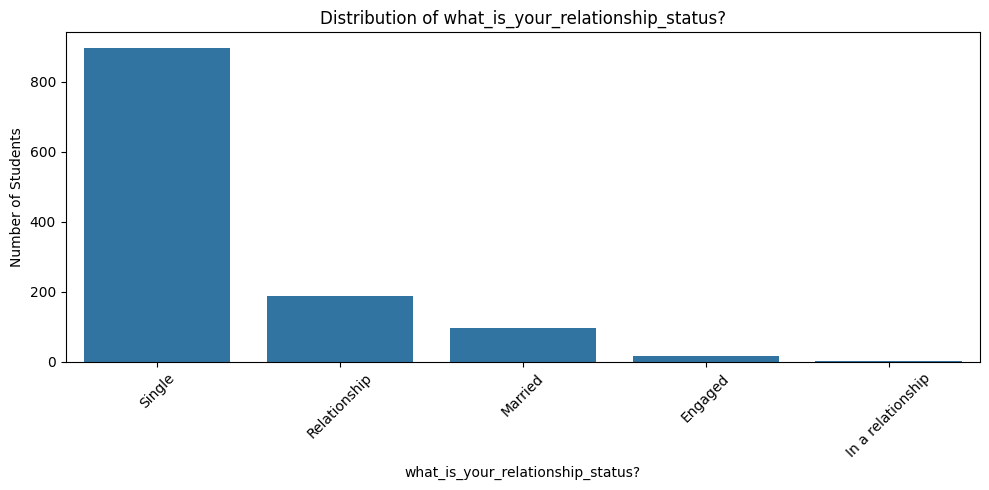

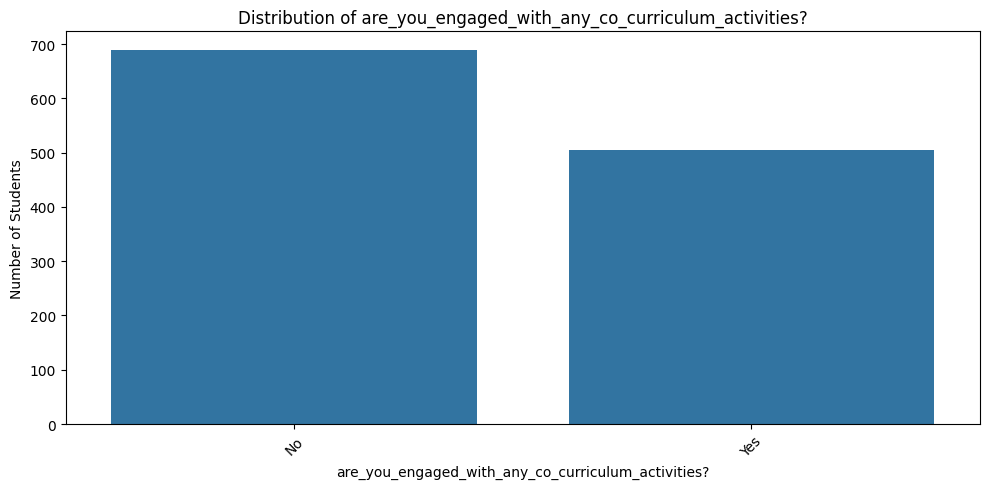

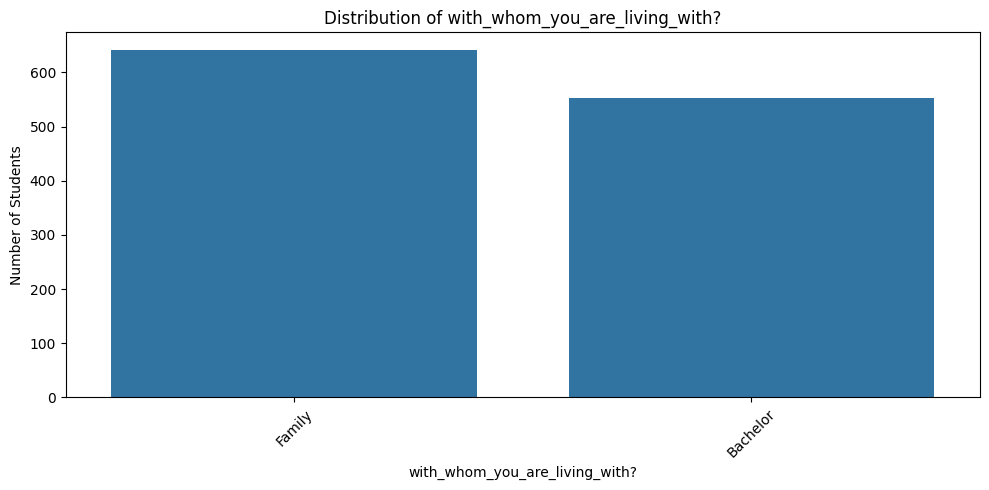

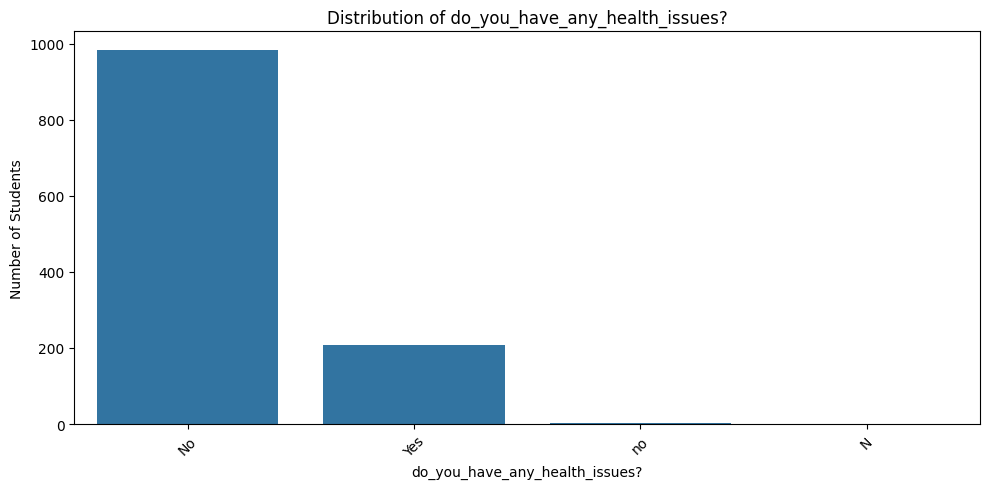

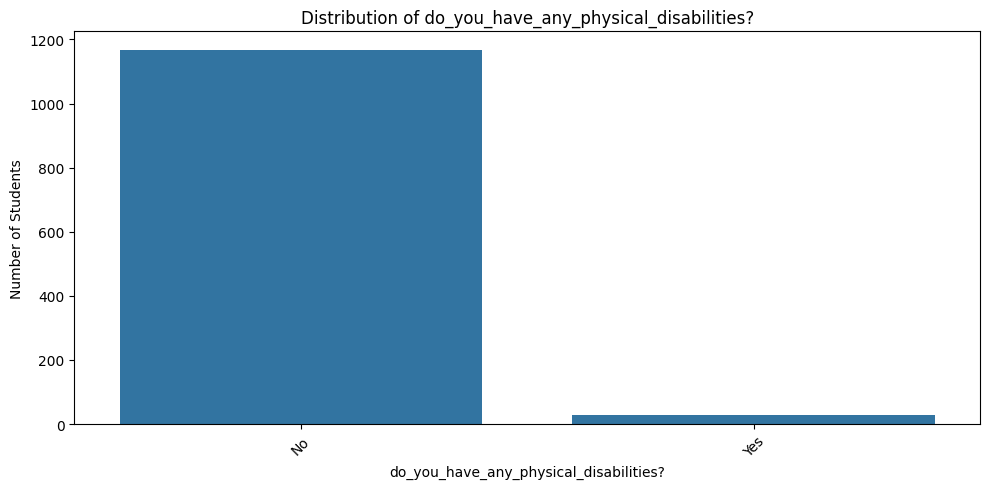

In [26]:
# ============================================
# CELL 9: CATEGORICAL DISTRIBUTIONS
# ============================================

categorical_columns = data.select_dtypes(
    include=["object", "category", "bool"]
).columns

for col in categorical_columns:

    if col == TARGET:
        continue

    plt.figure(figsize=(10, 5))

    order = data[col].value_counts().index

    sns.countplot(
        data=data,
        x=col,
        order=order
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Students")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

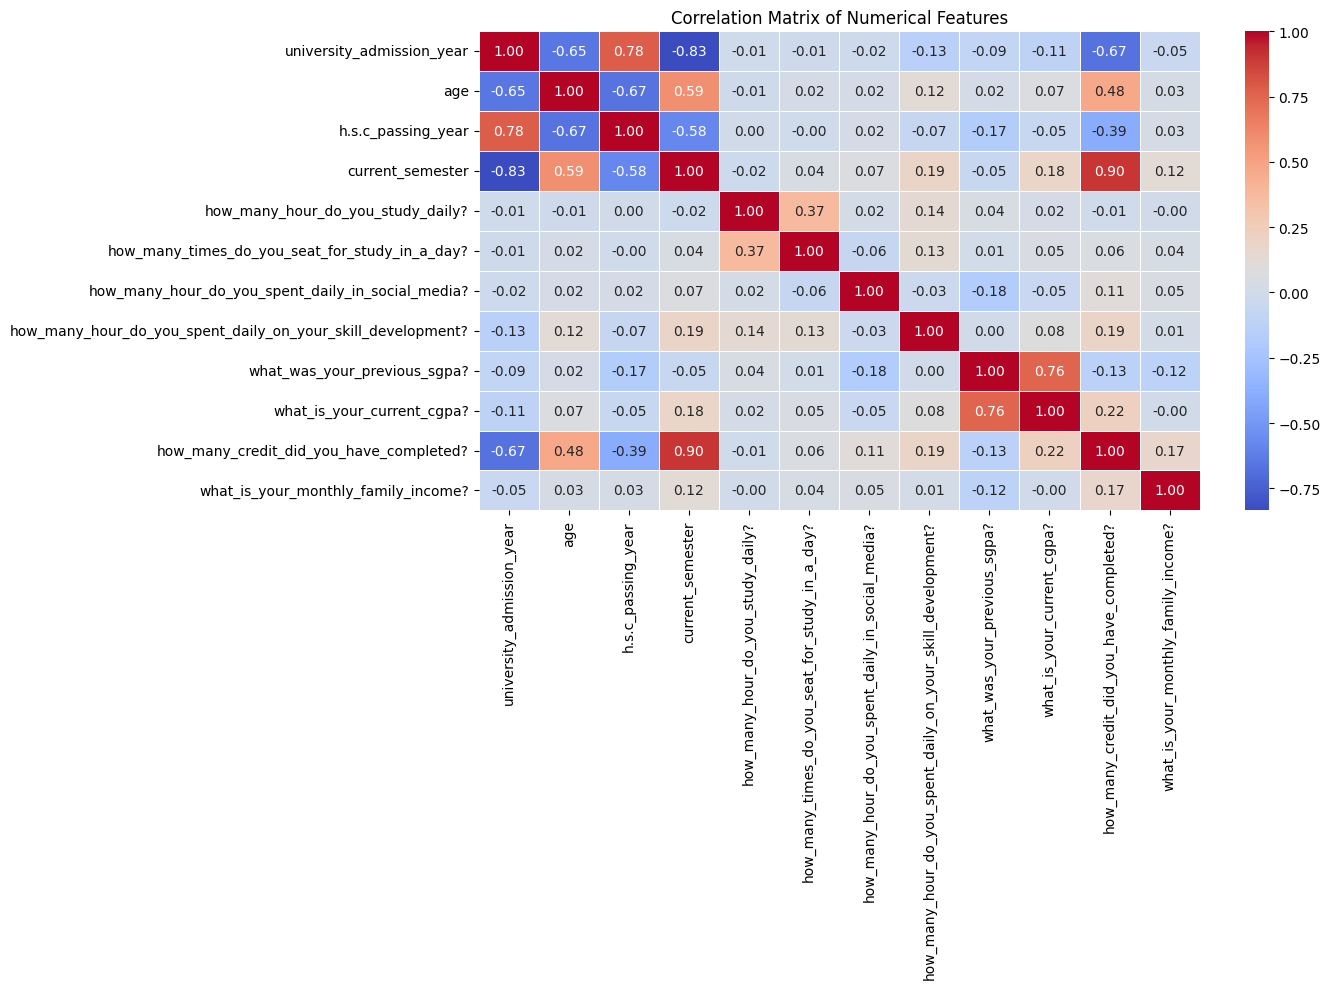

In [27]:
# ============================================
# CELL 10: CORRELATION HEATMAP
# ============================================

numeric_data = data.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
)

plt.figure(figsize=(14, 10))

correlation_matrix = numeric_data.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [28]:
# ============================================
# CELL 11: STUDENT STATUS ANALYSIS
# ============================================

if TARGET is not None:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=data,
        x=TARGET,
        order=data[TARGET].value_counts().index
    )

    plt.title("Student Status Distribution")
    plt.xlabel("Student Status")
    plt.ylabel("Number of Students")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()

In [29]:
# ============================================
# CELL 12: NUMERICAL FEATURES VS STUDENT STATUS
# ============================================

if TARGET is not None:

    numeric_features = data.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns

    for col in numeric_features:

        plt.figure(figsize=(9, 5))

        sns.boxplot(
            data=data,
            x=TARGET,
            y=col
        )

        plt.title(f"{col} vs {TARGET}")
        plt.xlabel("Student Status")
        plt.ylabel(col)

        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

In [36]:
# ============================================
# CELL 13: PREPARE DATA FOR MACHINE LEARNING
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ============================================
# 1. TARGET VARIABLE
# ============================================

TARGET_NUMERIC = "what_is_your_current_cgpa?"

if TARGET_NUMERIC not in data.columns:
    raise ValueError(
        f"Column '{TARGET_NUMERIC}' was not found. "
        f"Available columns: {list(data.columns)}"
    )

# ============================================
# 2. CLEAN TARGET COLUMN
# ============================================

data_ml = data.copy()

data_ml[TARGET_NUMERIC] = pd.to_numeric(
    data_ml[TARGET_NUMERIC],
    errors="coerce"
)

data_ml = data_ml.dropna(
    subset=[TARGET_NUMERIC]
).copy()

# ============================================
# 3. CREATE PERFORMANCE CLASS
# ============================================

def classify_performance(cgpa):

    if cgpa < 6.0:
        return "At Risk"

    elif cgpa < 7.5:
        return "Average"

    else:
        return "Good"


data_ml["performance_class"] = (
    data_ml[TARGET_NUMERIC]
    .apply(classify_performance)
)

TARGET = "performance_class"

# ============================================
# 4. REMOVE TARGET AND CGPA
# ============================================

X = data_ml.drop(
    columns=[
        TARGET,
        TARGET_NUMERIC
    ]
)

y = data_ml[TARGET].astype(str)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# ============================================
# 5. TARGET DISTRIBUTION
# ============================================

print("\n========== TARGET CLASSES ==========")
print(y.value_counts())

print("\n========== TARGET PERCENTAGE ==========")

print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# ============================================
# 6. ENCODE TARGET
# ============================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n========== TARGET ENCODING ==========")

for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

# ============================================
# 7. IDENTIFY FEATURE TYPES
# ============================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("\n========== NUMERICAL FEATURES ==========")
print(numeric_features)

print("\n========== CATEGORICAL FEATURES ==========")
print(categorical_features)

# ============================================
# 8. NUMERICAL PREPROCESSING
# ============================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ============================================
# 9. CATEGORICAL PREPROCESSING
# ============================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

# ============================================
# 10. COMBINED PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ============================================
# 11. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n========== TRAIN / TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nCell 13 completed successfully!")

Feature shape: (1194, 30)
Target shape: (1194,)

========== TARGET CLASSES ==========
performance_class
At Risk    1194
Name: count, dtype: int64

========== TARGET PERCENTAGE ==========
performance_class
At Risk    100.0
Name: proportion, dtype: float64

========== TARGET ENCODING ==========
0 = At Risk

========== NUMERICAL FEATURES ==========
['university_admission_year', 'age', 'h.s.c_passing_year', 'current_semester', 'how_many_hour_do_you_study_daily?', 'how_many_times_do_you_seat_for_study_in_a_day?', 'how_many_hour_do_you_spent_daily_in_social_media?', 'how_many_hour_do_you_spent_daily_on_your_skill_development?', 'what_was_your_previous_sgpa?', 'how_many_credit_did_you_have_completed?', 'what_is_your_monthly_family_income?']

========== CATEGORICAL FEATURES ==========
['gender', 'program', 'do_you_have_meritorious_scholarship_?', 'do_you_use_university_transportation?', 'what_is_your_preferable_learning_mode?', 'do_you_use_smart_phone?', 'do_you_have_personal_computer?', 'stat

In [39]:
# ============================================
# CELL 14: LOGISTIC REGRESSION MODEL - FIXED
# ============================================

# ============================================
# 1. CREATE BALANCED PERFORMANCE CLASSES
# ============================================

# Use the actual median CGPA of the dataset
median_cgpa = data_ml[TARGET_NUMERIC].median()

print("Median CGPA:", median_cgpa)

# Create two performance classes
data_ml["performance_class"] = np.where(
    data_ml[TARGET_NUMERIC] < median_cgpa,
    "At Risk",
    "Good"
)

TARGET = "performance_class"

# ============================================
# 2. PREPARE FEATURES AND TARGET
# ============================================

X = data_ml.drop(
    columns=[
        TARGET,
        TARGET_NUMERIC
    ]
)

y = data_ml[TARGET].astype(str)

# ============================================
# 3. ENCODE TARGET
# ============================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n========== PERFORMANCE CLASSES ==========")

print(
    y.value_counts()
)

print("\nPercentage:")

print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTarget encoding:")

for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

# ============================================
# 4. IDENTIFY FEATURES
# ============================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64",
        "int32",
        "float32"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

# ============================================
# 5. PREPROCESSING
# ============================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ============================================
# 6. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print(
    "\nTraining classes:",
    np.unique(y_train)
)

print(
    "Testing classes:",
    np.unique(y_test)
)

# ============================================
# 7. LOGISTIC REGRESSION
# ============================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

# Train
logistic_model.fit(
    X_train,
    y_train
)

# Predict
logistic_predictions = (
    logistic_model.predict(X_test)
)

# ============================================
# 8. MODEL METRICS
# ============================================

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("\n============================================")
print("       LOGISTIC REGRESSION RESULTS")
print("============================================")

print(
    "Accuracy :",
    round(logistic_accuracy, 4)
)

print(
    "Precision:",
    round(logistic_precision, 4)
)

print(
    "Recall   :",
    round(logistic_recall, 4)
)

print(
    "F1 Score :",
    round(logistic_f1, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

print("\nCell 14 completed successfully!")

Median CGPA: 3.21

========== PERFORMANCE CLASSES ==========
performance_class
Good       598
At Risk    596
Name: count, dtype: int64

Percentage:
performance_class
Good       50.08
At Risk    49.92
Name: proportion, dtype: float64

Target encoding:
0 = At Risk
1 = Good

Training samples: 955
Testing samples: 239

Training classes: [0 1]
Testing classes: [0 1]

       LOGISTIC REGRESSION RESULTS
Accuracy : 0.8661
Precision: 0.8671
Recall   : 0.8661
F1 Score : 0.866

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.85      0.89      0.87       119
        Good       0.89      0.84      0.86       120

    accuracy                           0.87       239
   macro avg       0.87      0.87      0.87       239
weighted avg       0.87      0.87      0.87       239


Cell 14 completed successfully!


In [40]:
# ============================================
# CELL 15: RANDOM FOREST MODEL
# ============================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train Random Forest
random_forest_model.fit(
    X_train,
    y_train
)

# Make predictions
rf_predictions = random_forest_model.predict(
    X_test
)

# Calculate metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average="weighted",
    zero_division=0
)

# Display results
print("============================================")
print("          RANDOM FOREST RESULTS")
print("============================================")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

          RANDOM FOREST RESULTS
Accuracy : 0.887
Precision: 0.8904
Recall   : 0.887
F1 Score : 0.8868

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.85      0.93      0.89       119
        Good       0.93      0.84      0.88       120

    accuracy                           0.89       239
   macro avg       0.89      0.89      0.89       239
weighted avg       0.89      0.89      0.89       239



In [41]:
# ============================================
# CELL 16: MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

model_comparison = model_comparison.round(4)

print("============================================")
print("             MODEL COMPARISON")
print("============================================")

display(model_comparison)

             MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8661,0.8671,0.8661,0.8660
1,Random Forest,0.8870,0.8904,0.8870,0.8868


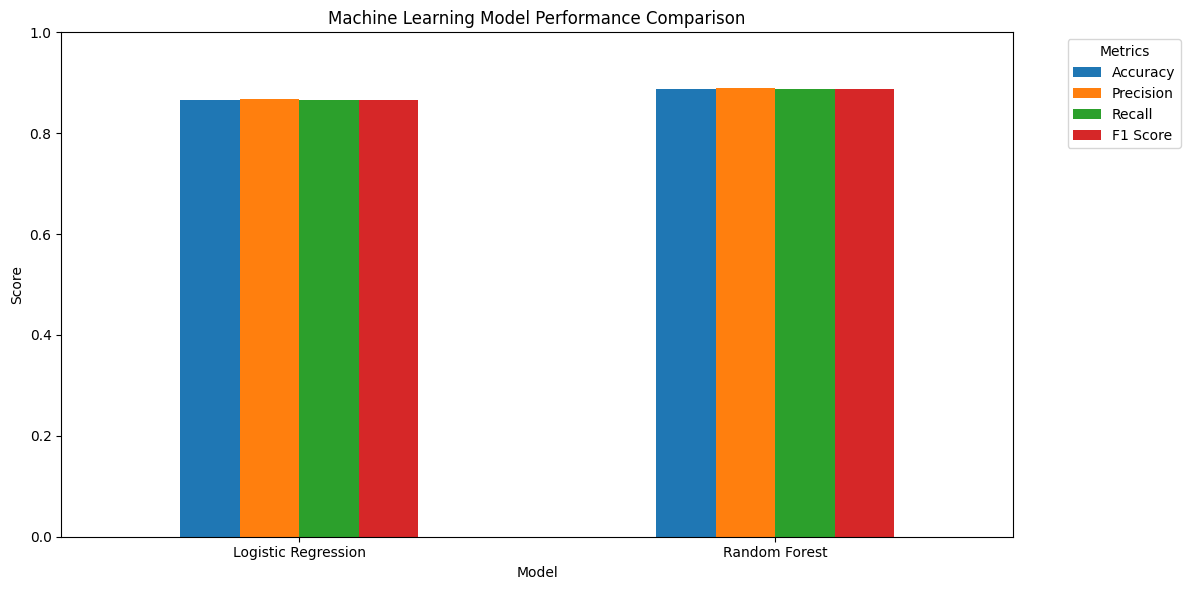

In [42]:
# ============================================
# CELL 17: MODEL PERFORMANCE GRAPH
# ============================================

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

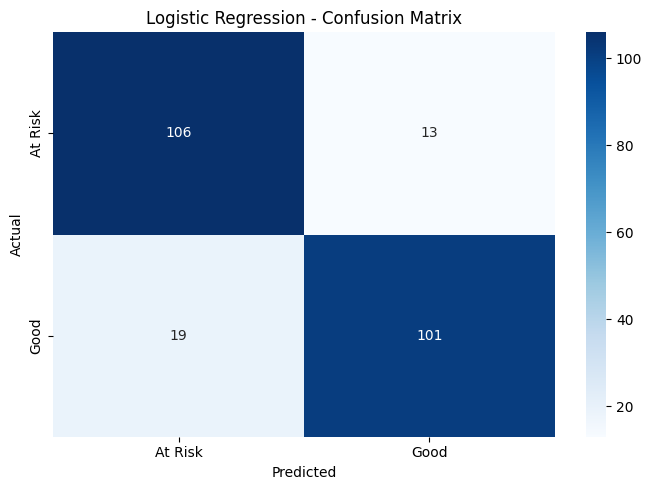

In [43]:
# ============================================
# CELL 18: LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================

cm_lr = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

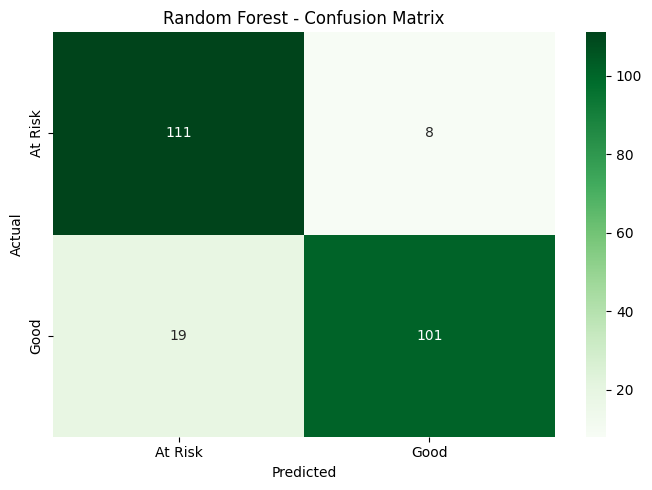

In [44]:
# ============================================
# CELL 19: RANDOM FOREST CONFUSION MATRIX
# ============================================

cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [45]:
# ============================================
# CELL 20: FEATURE IMPORTANCE
# ============================================

rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance_values = (
    rf_classifier.feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Clean feature names
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

print("Top 20 Important Features:")

display(
    feature_importance.head(20)
)

Top 20 Important Features:


,Feature,Importance
8,what_was_your_previous_sgpa?,0.270269
9,how_many_credit_did_you_have_completed?,0.061170
10,what_is_your_monthly_family_income?,0.045233
3,current_semester,0.037702
6,how_many_hour_do_you_spent_daily_in_social_media?,0.031894
4,how_many_hour_do_you_study_daily?,0.026452
1,age,0.025581
2,h.s.c_passing_year,0.025302
0,university_admission_year,0.023553
7,how_many_hour_do_you_spent_daily_on_your_skill...,0.023129


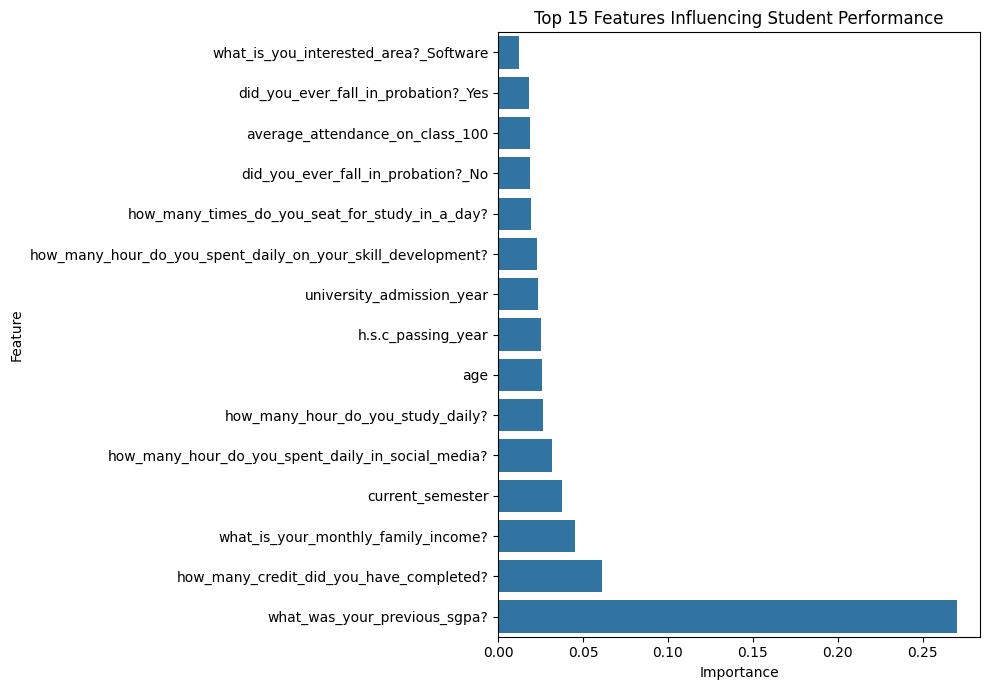

In [46]:
# ============================================
# CELL 21: FEATURE IMPORTANCE GRAPH
# ============================================

top_features = (
    feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Influencing Student Performance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [47]:
# ============================================
# CELL 22: ACTUAL VS PREDICTED PERFORMANCE
# ============================================

actual_labels = label_encoder.inverse_transform(
    y_test
)

predicted_labels = label_encoder.inverse_transform(
    rf_predictions
)

prediction_comparison = pd.DataFrame({
    "Actual": actual_labels,
    "Predicted": predicted_labels
})

print("Actual vs Predicted Performance:")

display(
    prediction_comparison.head(20)
)

comparison_counts = pd.crosstab(
    prediction_comparison["Actual"],
    prediction_comparison["Predicted"]
)

print("\nComparison Table:")

display(comparison_counts)

Actual vs Predicted Performance:


,Actual,Predicted
0,Good,Good
1,At Risk,At Risk
2,Good,Good
3,At Risk,At Risk
4,At Risk,At Risk
5,Good,Good
6,At Risk,At Risk
7,At Risk,At Risk
8,At Risk,At Risk
9,Good,Good



Comparison Table:


Predicted,At Risk,Good
Actual,,
At Risk,111,8
Good,19,101


In [48]:
# ============================================
# CELL 23: FINAL MODEL TRAINING
# ============================================

final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train using all available data
final_model.fit(
    X,
    y_encoded
)

print("Final Random Forest model trained successfully!")

Final Random Forest model trained successfully!


In [49]:
# ============================================
# CELL 24: PREDICT PERFORMANCE FOR ALL STUDENTS
# ============================================

all_predictions = final_model.predict(X)

all_probabilities = final_model.predict_proba(X)

# Highest class probability
prediction_confidence = (
    all_probabilities.max(axis=1) * 100
).round(2)

# Create prediction results
prediction_results = data_ml.copy()

prediction_results["Predicted_Performance"] = (
    label_encoder.inverse_transform(
        all_predictions
    )
)

prediction_results["Prediction_Confidence"] = (
    prediction_confidence
)

# Create Student ID
prediction_results.insert(
    0,
    "Student_ID",
    [
        f"STU_{i:04d}"
        for i in range(
            1,
            len(prediction_results) + 1
        )
    ]
)

print("Prediction results created successfully!")

display(
    prediction_results.head(10)
)

Prediction results created successfully!


,Student_ID,university_admission_year,gender,age,h.s.c_passing_year,program,current_semester,do_you_have_meritorious_scholarship_?,do_you_use_university_transportation?,how_many_hour_do_you_study_daily?,how_many_times_do_you_seat_for_study_in_a_day?,what_is_your_preferable_learning_mode?,do_you_use_smart_phone?,do_you_have_personal_computer?,how_many_hour_do_you_spent_daily_in_social_media?,status_of_your_english_language_proficiency,average_attendance_on_class,did_you_ever_fall_in_probation?,did_you_ever_got_suspension?,do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems?,what_are_the_skills_do_you_have_?,how_many_hour_do_you_spent_daily_on_your_skill_development?,what_is_you_interested_area?,what_is_your_relationship_status?,are_you_engaged_with_any_co_curriculum_activities?,with_whom_you_are_living_with?,do_you_have_any_health_issues?,what_was_your_previous_sgpa?,do_you_have_any_physical_disabilities?,what_is_your_current_cgpa?,how_many_credit_did_you_have_completed?,what_is_your_monthly_family_income?,performance_class,Predicted_Performance,Prediction_Confidence
0,STU_0001,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000,At Risk,At Risk,84.67
1,STU_0002,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000,At Risk,At Risk,89.33
2,STU_0003,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000,At Risk,At Risk,87.33
3,STU_0004,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488,At Risk,At Risk,88.33
4,STU_0005,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000,At Risk,At Risk,90.00
5,STU_0006,2021,Male,20,2020,BCSE,4,Yes,Yes,2,2,Offline,Yes,Yes,1,Intermediate,95,No,No,Yes,Web development,2,Software,Single,Yes,Family,No,2.68,No,3.15,36,30000,At Risk,At Risk,90.00
6,STU_0007,2021,Male,22,2018,BCSE,4,Yes,No,2,4,Online,Yes,Yes,2,Intermediate,80,No,No,No,Web development,6,Software,Single,No,Bachelor,Yes,2.68,No,3.15,36,20000,At Risk,At Risk,88.33
7,STU_0008,2021,Female,22,2019,BCSE,4,Yes,No,2,2,Offline,Yes,Yes,2,Basic,100,Yes,No,Yes,Web development,1,NETWORKING,Single,No,Bachelor,No,3.80,No,3.64,35,32500,Good,Good,82.33
8,STU_0009,2021,Male,20,2020,BCSE,4,Yes,No,3,2,Offline,Yes,Yes,2,Intermediate,90,No,No,No,Programming,3,Software,Single,No,Bachelor,No,2.68,No,3.15,36,20000,At Risk,At Risk,95.33
9,STU_0010,2021,Female,22,2020,BCSE,4,Yes,Yes,5,2,Offline,Yes,Yes,2,Intermediate,100,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Family,No,2.68,No,3.15,36,25000,At Risk,At Risk,85.33


In [50]:
# ============================================
# CELL 25: PREDICTION CONFIDENCE LEVEL
# ============================================

def confidence_level(value):

    if value >= 80:
        return "High Confidence"

    elif value >= 60:
        return "Medium Confidence"

    else:
        return "Low Confidence"


prediction_results["Confidence_Level"] = (
    prediction_results[
        "Prediction_Confidence"
    ].apply(confidence_level)
)

print("Prediction Confidence Distribution:")

display(
    prediction_results[
        "Confidence_Level"
    ].value_counts()
    .to_frame("Students")
)

Prediction Confidence Distribution:


,Students
Confidence_Level,
High Confidence,1101
Medium Confidence,93


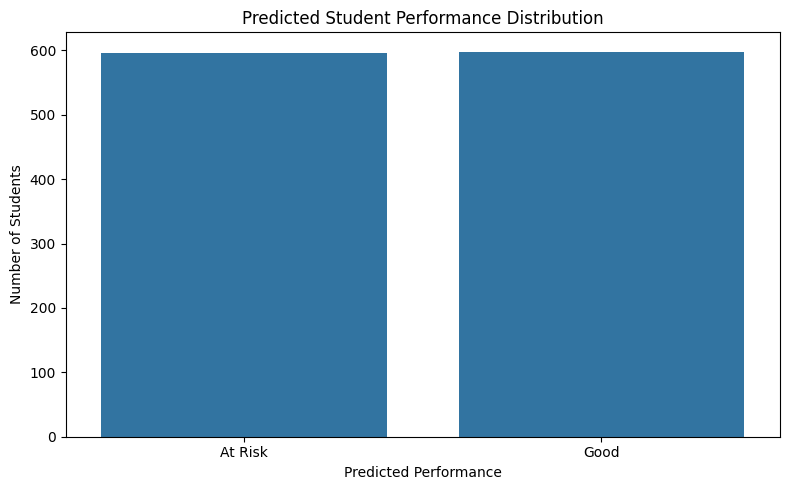

In [51]:
# ============================================
# CELL 26: PREDICTED PERFORMANCE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

order = [
    "At Risk",
    "Good"
]

sns.countplot(
    data=prediction_results,
    x="Predicted_Performance",
    order=order
)

plt.title(
    "Predicted Student Performance Distribution"
)

plt.xlabel("Predicted Performance")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

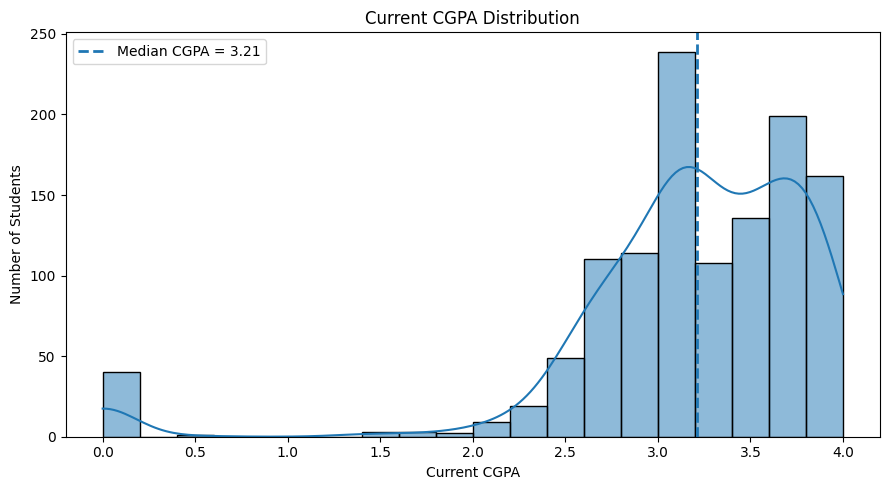

In [52]:
# ============================================
# CELL 27: CGPA DISTRIBUTION
# ============================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=data_ml,
    x=TARGET_NUMERIC,
    bins=20,
    kde=True
)

plt.axvline(
    median_cgpa,
    linestyle="--",
    linewidth=2,
    label=f"Median CGPA = {median_cgpa:.2f}"
)

plt.title("Current CGPA Distribution")
plt.xlabel("Current CGPA")
plt.ylabel("Number of Students")

plt.legend()

plt.tight_layout()
plt.show()

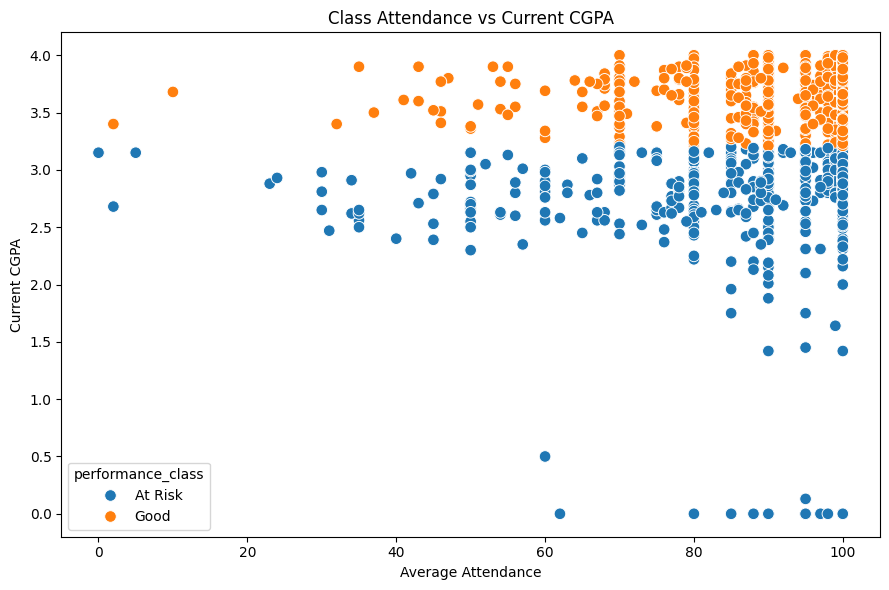

In [53]:
# ============================================
# CELL 28: ATTENDANCE VS CGPA
# ============================================

attendance_column = "average_attendance_on_class"

if attendance_column in data_ml.columns:

    attendance_numeric = pd.to_numeric(
        data_ml[attendance_column],
        errors="coerce"
    )

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        x=attendance_numeric,
        y=data_ml[TARGET_NUMERIC],
        hue=data_ml["performance_class"],
        s=70
    )

    plt.title(
        "Class Attendance vs Current CGPA"
    )

    plt.xlabel("Average Attendance")
    plt.ylabel("Current CGPA")

    plt.tight_layout()
    plt.show()

else:

    print(
        f"Column '{attendance_column}' was not found."
    )

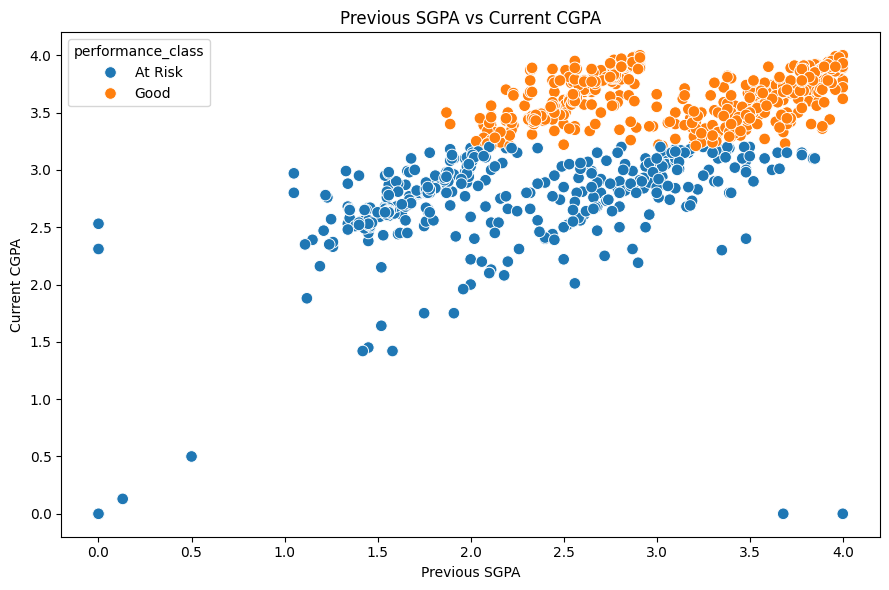

In [54]:
# ============================================
# CELL 29: PREVIOUS SGPA VS CURRENT CGPA
# ============================================

sgpa_column = "what_was_your_previous_sgpa?"

if sgpa_column in data_ml.columns:

    previous_sgpa = pd.to_numeric(
        data_ml[sgpa_column],
        errors="coerce"
    )

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        x=previous_sgpa,
        y=data_ml[TARGET_NUMERIC],
        hue=data_ml["performance_class"],
        s=70
    )

    plt.title(
        "Previous SGPA vs Current CGPA"
    )

    plt.xlabel("Previous SGPA")
    plt.ylabel("Current CGPA")

    plt.tight_layout()
    plt.show()

else:

    print(
        f"Column '{sgpa_column}' was not found."
    )

Performance Percentage by Daily Study Hours:


performance_class,At Risk,Good
how_many_hour_do_you_study_daily?,,
0,33.33,66.67
1,50.00,50.00
2,51.75,48.25
3,54.40,45.60
4,49.72,50.28
5,41.13,58.87
6,44.26,55.74
7,42.11,57.89
8,40.00,60.00


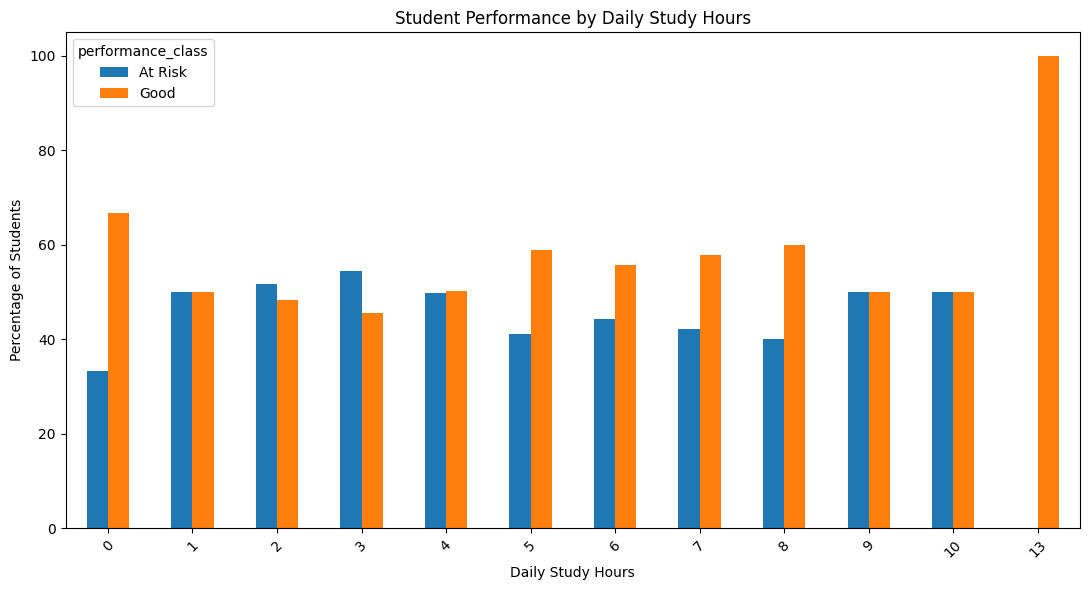

In [55]:
# ============================================
# CELL 30: STUDY HOURS VS PERFORMANCE
# ============================================

study_column = "how_many_hour_do_you_study_daily?"

if study_column in data_ml.columns:

    study_summary = pd.crosstab(
        data_ml[study_column],
        data_ml["performance_class"],
        normalize="index"
    ) * 100

    study_summary = study_summary.round(2)

    print(
        "Performance Percentage by Daily Study Hours:"
    )

    display(study_summary)

    study_summary.plot(
        kind="bar",
        figsize=(11, 6)
    )

    plt.title(
        "Student Performance by Daily Study Hours"
    )

    plt.xlabel("Daily Study Hours")
    plt.ylabel("Percentage of Students")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:

    print(
        f"Column '{study_column}' was not found."
    )

In [56]:
# ============================================
# CELL 31: ENGLISH PROFICIENCY VS PERFORMANCE
# ============================================

english_column = (
    "status_of_your_english_language_proficiency"
)

if english_column in data_ml.columns:

    english_summary = pd.crosstab(
        data_ml[english_column],
        data_ml["performance_class"],
        normalize="index"
    ) * 100

    english_summary = english_summary.round(2)

    print(
        "Performance Percentage by English Proficiency:"
    )

    display(english_summary)

else:

    print(
        f"Column '{english_column}' was not found."
    )

Performance Percentage by English Proficiency:


performance_class,At Risk,Good
status_of_your_english_language_proficiency,,
Advance,46.36,53.64
Basic,58.88,41.12
Intermediate,47.01,52.99


In [57]:
# ============================================
# CELL 32: SCHOLARSHIP VS PERFORMANCE
# ============================================

scholarship_column = (
    "do_you_have_meritorious_scholarship_?"
)

if scholarship_column in data_ml.columns:

    scholarship_summary = pd.crosstab(
        data_ml[scholarship_column],
        data_ml["performance_class"],
        normalize="index"
    ) * 100

    scholarship_summary = (
        scholarship_summary.round(2)
    )

    print(
        "Performance Percentage by Scholarship Status:"
    )

    display(scholarship_summary)

else:

    print(
        f"Column '{scholarship_column}' "
        "was not found."
    )

Performance Percentage by Scholarship Status:


performance_class,At Risk,Good
do_you_have_meritorious_scholarship_?,,
No,56.04,43.96
Yes,42.07,57.93


In [58]:
# ============================================
# CELL 33: IDENTIFY AT-RISK STUDENTS
# ============================================

at_risk_students = prediction_results[
    prediction_results["Predicted_Performance"] == "At Risk"
].copy()

print(
    "Number of predicted At-Risk students:",
    len(at_risk_students)
)

print(
    "Percentage of predicted At-Risk students:",
    round(
        len(at_risk_students)
        / len(prediction_results)
        * 100,
        2
    ),
    "%"
)

display(
    at_risk_students.head(20)
)

Number of predicted At-Risk students: 596
Percentage of predicted At-Risk students: 49.92 %


,Student_ID,university_admission_year,gender,age,h.s.c_passing_year,program,current_semester,do_you_have_meritorious_scholarship_?,do_you_use_university_transportation?,how_many_hour_do_you_study_daily?,how_many_times_do_you_seat_for_study_in_a_day?,what_is_your_preferable_learning_mode?,do_you_use_smart_phone?,do_you_have_personal_computer?,how_many_hour_do_you_spent_daily_in_social_media?,status_of_your_english_language_proficiency,average_attendance_on_class,did_you_ever_fall_in_probation?,did_you_ever_got_suspension?,do_you_attend_in_teacher_consultancy_for_any_kind_of_academical_problems?,what_are_the_skills_do_you_have_?,how_many_hour_do_you_spent_daily_on_your_skill_development?,what_is_you_interested_area?,what_is_your_relationship_status?,are_you_engaged_with_any_co_curriculum_activities?,with_whom_you_are_living_with?,do_you_have_any_health_issues?,what_was_your_previous_sgpa?,do_you_have_any_physical_disabilities?,what_is_your_current_cgpa?,how_many_credit_did_you_have_completed?,what_is_your_monthly_family_income?,performance_class,Predicted_Performance,Prediction_Confidence,Confidence_Level
0,STU_0001,2018,Male,24,2016,BCSE,12,Yes,No,3,2,Offline,Yes,Yes,5,Intermediate,90,No,No,Yes,Software Development,2,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000,At Risk,At Risk,84.67,High Confidence
1,STU_0002,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Basic,96,Yes,No,No,Web development,2,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000,At Risk,At Risk,89.33,High Confidence
2,STU_0003,2020,Female,21,2019,BCSE,5,No,No,3,3,Offline,Yes,Yes,3,Intermediate,80,No,No,Yes,Programming,1,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000,At Risk,At Risk,87.33,High Confidence
3,STU_0004,2021,Male,20,2020,BCSE,4,Yes,No,1,3,Offline,Yes,Yes,2,Intermediate,88,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488,At Risk,At Risk,88.33,High Confidence
4,STU_0005,2021,Male,22,2019,BCSE,4,Yes,No,3,1,Online,Yes,Yes,2,Intermediate,80,No,No,Yes,Programming,1,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000,At Risk,At Risk,90.00,High Confidence
5,STU_0006,2021,Male,20,2020,BCSE,4,Yes,Yes,2,2,Offline,Yes,Yes,1,Intermediate,95,No,No,Yes,Web development,2,Software,Single,Yes,Family,No,2.68,No,3.15,36,30000,At Risk,At Risk,90.00,High Confidence
6,STU_0007,2021,Male,22,2018,BCSE,4,Yes,No,2,4,Online,Yes,Yes,2,Intermediate,80,No,No,No,Web development,6,Software,Single,No,Bachelor,Yes,2.68,No,3.15,36,20000,At Risk,At Risk,88.33,High Confidence
8,STU_0009,2021,Male,20,2020,BCSE,4,Yes,No,3,2,Offline,Yes,Yes,2,Intermediate,90,No,No,No,Programming,3,Software,Single,No,Bachelor,No,2.68,No,3.15,36,20000,At Risk,At Risk,95.33,High Confidence
9,STU_0010,2021,Female,22,2020,BCSE,4,Yes,Yes,5,2,Offline,Yes,Yes,2,Intermediate,100,No,No,Yes,Programming,1,Artificial Intelligence,Single,No,Family,No,2.68,No,3.15,36,25000,At Risk,At Risk,85.33,High Confidence
10,STU_0011,2021,Male,22,2019,BCSE,4,Yes,Yes,3,2,Online,Yes,Yes,3,Intermediate,90,No,No,Yes,Programming,1,Software,Single,Yes,Family,No,2.68,No,3.15,36,50000,At Risk,At Risk,88.00,High Confidence


In [59]:
# ============================================
# CELL 34: AT-RISK STUDENT SUMMARY
# ============================================

print("============================================")
print("          AT-RISK STUDENT ANALYSIS")
print("============================================")

print(
    "Total Students:",
    len(prediction_results)
)

print(
    "Predicted At-Risk:",
    len(at_risk_students)
)

print(
    "Predicted Good:",
    len(
        prediction_results[
            prediction_results[
                "Predicted_Performance"
            ] == "Good"
        ]
    )
)

print(
    "\nAverage CGPA of At-Risk Students:",
    round(
        at_risk_students[TARGET_NUMERIC].mean(),
        2
    )
)

print(
    "Average CGPA of Good Students:",
    round(
        prediction_results[
            prediction_results[
                "Predicted_Performance"
            ] == "Good"
        ][TARGET_NUMERIC].mean(),
        2
    )
)

          AT-RISK STUDENT ANALYSIS
Total Students: 1194
Predicted At-Risk: 596
Predicted Good: 598

Average CGPA of At-Risk Students: 2.68
Average CGPA of Good Students: 3.65


In [60]:
# ============================================
# CELL 35: FINAL MODEL FEATURE IMPORTANCE
# ============================================

final_preprocessor = (
    final_model
    .named_steps["preprocessor"]
)

final_classifier = (
    final_model
    .named_steps["classifier"]
)

final_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

final_importance_values = (
    final_classifier.feature_importances_
)

final_feature_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_importance_values
})

final_feature_importance = (
    final_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

final_feature_importance["Feature"] = (
    final_feature_importance["Feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

print("Top 20 Final Model Features:")

display(
    final_feature_importance.head(20)
)

Top 20 Final Model Features:


,Feature,Importance
8,what_was_your_previous_sgpa?,0.271946
9,how_many_credit_did_you_have_completed?,0.060809
10,what_is_your_monthly_family_income?,0.046684
3,current_semester,0.039652
6,how_many_hour_do_you_spent_daily_in_social_media?,0.030155
4,how_many_hour_do_you_study_daily?,0.027675
1,age,0.026461
2,h.s.c_passing_year,0.025488
0,university_admission_year,0.024883
7,how_many_hour_do_you_spent_daily_on_your_skill...,0.023778


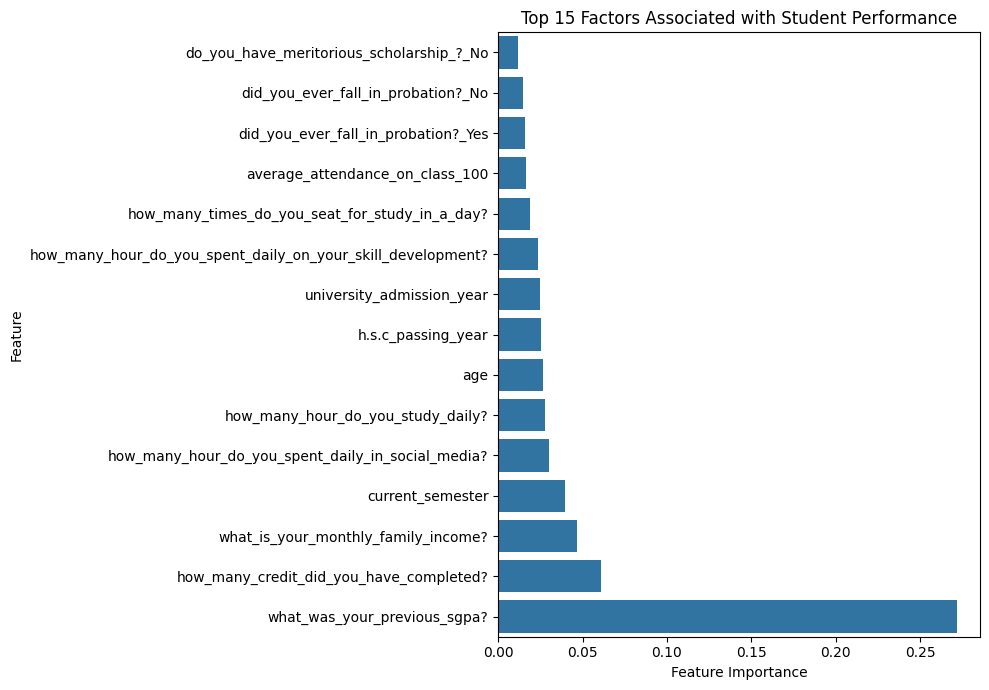

In [61]:
# ============================================
# CELL 36: FINAL FEATURE IMPORTANCE GRAPH
# ============================================

top_final_features = (
    final_feature_importance
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_final_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Factors Associated with Student Performance"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [62]:
# ============================================
# CELL 37: SAVE PREDICTION RESULTS
# ============================================

OUTPUT_PATH = (
    "/kaggle/working/"
    "student_prediction_results.csv"
)

prediction_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Prediction results saved successfully!")
print()
print("File location:")
print(OUTPUT_PATH)

Prediction results saved successfully!

File location:
/kaggle/working/student_prediction_results.csv


In [63]:
# ============================================
# CELL 38: SAVE MODEL COMPARISON
# ============================================

MODEL_OUTPUT_PATH = (
    "/kaggle/working/"
    "model_comparison.csv"
)

model_comparison.to_csv(
    MODEL_OUTPUT_PATH,
    index=False
)

print("Model comparison saved successfully!")
print(MODEL_OUTPUT_PATH)

Model comparison saved successfully!
/kaggle/working/model_comparison.csv


In [64]:
# ============================================
# CELL 39: FINAL PROJECT KPI SUMMARY
# ============================================

total_students = len(prediction_results)

at_risk_count = len(
    prediction_results[
        prediction_results[
            "Predicted_Performance"
        ] == "At Risk"
    ]
)

good_count = len(
    prediction_results[
        prediction_results[
            "Predicted_Performance"
        ] == "Good"
    ]
)

at_risk_percentage = (
    at_risk_count / total_students * 100
)

good_percentage = (
    good_count / total_students * 100
)

average_cgpa = data_ml[
    TARGET_NUMERIC
].mean()

median_cgpa = data_ml[
    TARGET_NUMERIC
].median()

print("============================================")
print("       STUDENT PERFORMANCE ANALYTICS")
print("              KPI SUMMARY")
print("============================================")

print(
    f"\nTotal Students       : {total_students}"
)

print(
    f"Average CGPA        : {average_cgpa:.2f}"
)

print(
    f"Median CGPA         : {median_cgpa:.2f}"
)

print(
    f"Predicted At Risk   : {at_risk_count}"
)

print(
    f"At Risk Percentage  : {at_risk_percentage:.2f}%"
)

print(
    f"Predicted Good      : {good_count}"
)

print(
    f"Good Percentage     : {good_percentage:.2f}%"
)

print(
    f"\nLogistic Accuracy   : "
    f"{logistic_accuracy:.2%}"
)

print(
    f"Random Forest Accuracy: "
    f"{rf_accuracy:.2%}"
)

print("\n============================================")
print("              PROJECT COMPLETE")
print("============================================")

       STUDENT PERFORMANCE ANALYTICS
              KPI SUMMARY

Total Students       : 1194
Average CGPA        : 3.17
Median CGPA         : 3.21
Predicted At Risk   : 596
At Risk Percentage  : 49.92%
Predicted Good      : 598
Good Percentage     : 50.08%

Logistic Accuracy   : 86.61%
Random Forest Accuracy: 88.70%

              PROJECT COMPLETE
